### 1. Mi az az idősor (Time Series)

Egy **idősor** olyan adatstruktúra, amelyben az **adatpontokat időrendben** rögzítjük, jellemzően **egyenlő időközönként** – például percenként, naponta, havonta vagy évente.  
Minden méréshez tartozik egy **időbélyeg (timestamp)**, amely meghatározza, **mikor** történt a megfigyelés.


<div style="text-align:center;">
  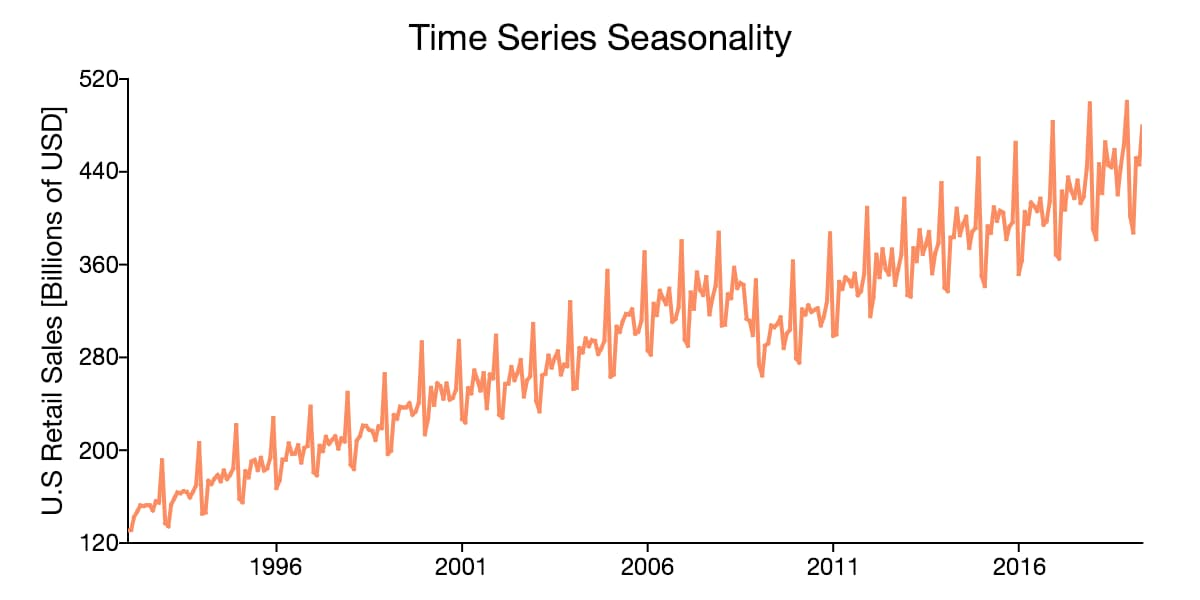
  <p style="font-style:italic; color:gray; margin-top:6px;">
    1. ábra. – Idősor trendet és szezonalitást mutató példája
  </p>
</div>

Az idősorok különlegesek, mert **az időbeli sorrend** önmagában is információt hordoz: nem mindegy, hogy egy érték előtt vagy után következik egy másik.  

<div style="background-color:#f5f0ff; border-left:6px solid #a855f7; padding:12px; border-radius:8px;">
<b>Például:</b><br>
Egy 10°C-os hőmérséklet télen és nyáron mást jelent, és a mai érték gyakran <strong>összefüggésben van</strong> a tegnapival — ezt nevezzük **időbeli autokorrelációnak**.
</div>


<br> 
<strong> Miért fontos az idősor-elemzés?</strong> 
<br> 
Az idősor-elemzés célja, hogy **megértsük a múltbeli viselkedést** és **előrejelezzük a jövőt**.  
A leggyakoribb felhasználási területek:

1. **Előrejelzés (Forecasting)**  
        - Időjárás, árfolyam, energiafogyasztás, sörfogyás, vagy akár weboldal-forgalom becslése.  
        - Példa: *„Holnap mennyi lesz a hőmérséklet vagy a villamosenergia-igény?”*

2. **Mintázat- és hasonlóságkeresés (Pattern & Similarity)**  
        - Azonos viselkedésű sorozatok felismerése: például melyik weboldal-látogató viselkedik hasonlóan, mint az aktuális felhasználó.  
        - Ilyen megközelítést használunk az **ajánlórendszerekben** is.

3. **Trendek és szezonalitás felismerése (Trend & Seasonality)**  
        - Hosszú távú növekedések vagy ciklikus minták azonosítása.
        - Példa: *„Nyáron több a fagyieladás, télen több a fűtésenergia-fogyasztás.”*




<div style="background-color:#e8fbe8; border-left:6px solid #16a34a; padding:12px; border-radius:8px;">

<b><strong>Példák idősorokra</strong></b><br>


| Terület | Idősor jellemzője | Mérési egység |
|----------|-------------------|---------------|
| Meteorológia | Hőmérséklet naponta | °C |
| Pénzügy | Részvényárfolyam percenként | USD |
| Mezőgazdaság | Napi csapadékmennyiség | mm |
| Kereskedelem | Napi eladások egy boltban | db |
| Egészségügy | Pulzus másodpercenként | bpm |

</div>

<br>

**Összefoglalás:**

Az idősorok **nem csak adatok**, hanem **történetek az időben**.  
Egy idősor elemzése segít megérteni, **hogyan változik egy jelenség**, milyen **minták ismétlődnek**, és **mit várhatunk a jövőben**.




### 2. Idősor példa – repülőutasok száma

Az idősor-elemzés egyik klasszikus példája az **Airline Passengers dataset**, amely egy amerikai légitársaság utasforgalmát mutatja be **1949 és 1960** között.  
A dataset azt tartalmazza, hogy **hány utas utazott havonta** a vizsgált időszakban.

<div style="text-align:center;">
  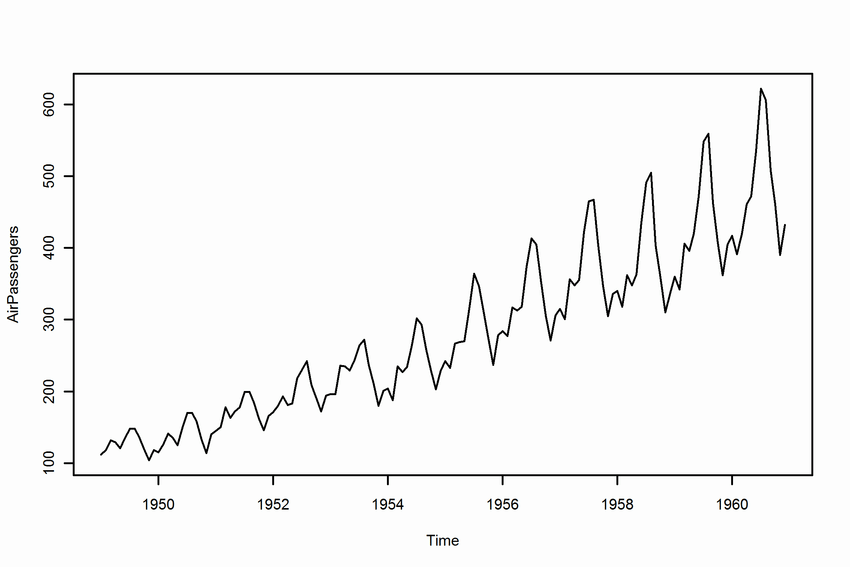
  <p style="font-style:italic; color:gray; margin-top:6px;">
    2. ábra. – Idősor a repülőutasok számáról
  </p>
</div>

Ez az adathalmaz tökéletes gyakorlóanyag, mert:
- jól látható benne a **trend** (az utasok száma évről évre nő),  
- megfigyelhető a **szezonalitás** (nyári hónapokban mindig több az utazás),  
- és tartalmaz némi **véletlen zajt** is, ami a valós adatokra jellemző.

<div style="background-color:#f5f0ff; border-left:6px solid #a855f7; padding:12px; border-radius:8px;">
<b>A célunk az lesz, hogy:</b><br>
    
1. betöltsük az adatot Pythonban,  
2. megvizsgáljuk az idősor szerkezetét,  
3. majd azonosítsuk a trendet és szezonalitást.
</div>





In [291]:
# Töltsük le tehát az `airline-passengers.csv` fájlt GitHubról, és nyissuk meg a Colab-ban vagy a Jupyterben.
import pandas as pd

# Adathalmaz betöltése
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

# Az első 5 sor megtekintése
print(df.head())


     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121


In [293]:
# Jelenleg a time oszlopunk csak string. Konvertáljuk át igazi dátum típussá:
df.Month = pd.to_datetime(df.Month)
print(df.Month.min() , "\n" , df.Month.max())

1949-01-01 00:00:00 
 1960-12-01 00:00:00


#### 2.1. Az idősor vizualizálása

Mielőtt bármilyen statisztikai vagy gépi tanulási módszert alkalmaznánk, érdemes **megnézni, hogyan néz ki az adatsor vizuálisan**.  
Egy egyszerű vonaldiagram már sokat elárul arról, hogy:
- van-e **növekvő vagy csökkenő trend**,  
- megfigyelhető-e **szezonalitás** (éves, havi, heti ciklusok),  
- illetve előfordulnak-e **kiugró értékek** vagy **zajos időszakok**.

Az idősorok egyik fő jellemzője, hogy **az idő múlásával változnak**, ezért az adatok időbeli elhelyezkedése kulcsfontosságú az értelmezéshez.


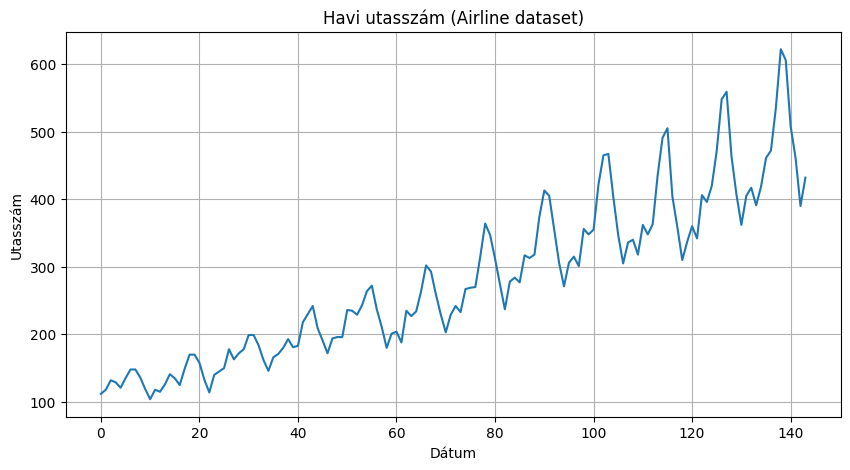

In [296]:
import matplotlib.pyplot as plt

# Egyszerű vonaldiagram
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Passengers'])
plt.title('Havi utasszám (Airline dataset)')
plt.xlabel('Dátum')
plt.ylabel('Utasszám')
plt.grid(True)
plt.show()


<strong>Mit figyelhetünk meg ezen a grafikonon?</strong>

- **Trend:** Hosszú távon egyértelmű növekedés látható az utasszámban.  
  Ez arra utal, hogy az évek során egyre többen utaztak repülővel.

- **Szezonalitás:** Évenként ismétlődő hullámok figyelhetők meg.  
  Nyári hónapokban (pl. július–augusztus) mindig magasabb az utasszám, míg télen visszaesik.

- **Volatilitás:** A változások mértéke az idő előrehaladtával növekszik.  
  A görbe „kilengései” egyre nagyobbak – vagyis az utasforgalom nemcsak nő, hanem egyre ingadozóbb is.

<div style="background-color:#e8fbe8; border-left:6px solid #16a34a; padding:12px; border-radius:8px;">
<b><strong>Megjegyzés:</strong></b><br>

- Ez a vizuális elemzés segít eldönteni, milyen modell illik az adatra (pl. additív vagy multiplikatív modell),  
- és hogy szükséges-e a szezonalitás vagy trend kiszűrése a további lépések előtt.
</div>





#### 2.2. Idősor vizsgálata éves bontásban

Miután megismertük az idősor általános trendjét, érdemes megnézni, **hogyan változott a havi utasszám évről évre**.  
Az éves csoportosítás segít abban, hogy **egymás mellé helyezve** lássuk az egyes évek mintáit — így kiderül, vajon minden évben hasonlóan alakulnak-e a csúcsidőszakok.

Ez a módszer segít:
- a **szezonalitás** (éves ismétlődések) megértésében,  
- a **trend** (növekedés vagy csökkenés) könnyebb felismerésében,  
- és abban, hogy gyorsan összehasonlítsuk az **év eleji és év végi értékeket**.


C:\Users\koros\AppData\Local\Temp\ipykernel_45148\872023751.py:7: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  groups = df.groupby(Grouper(freq='A'))


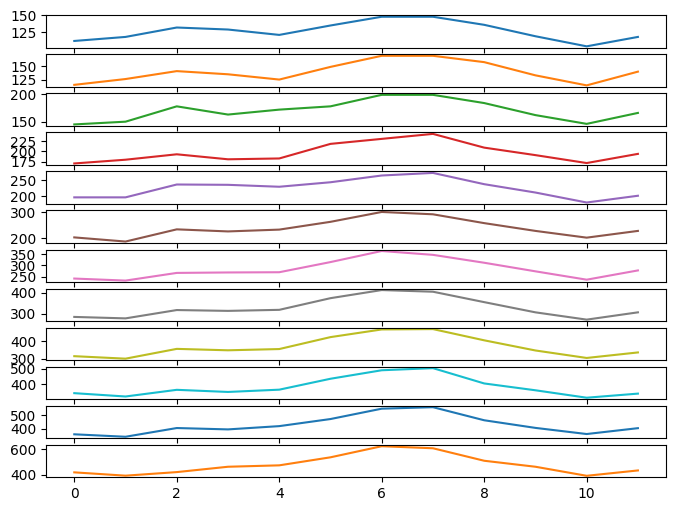

In [300]:
from pandas import DataFrame
from pandas import Grouper

# ha az idő lesz az index ("sorok nevei") akkor könnyebben tudjuk majd használni a dataframe-et:
df = df.set_index('Month')
# éves csoportositás
groups = df.groupby(Grouper(freq='A'))
## évekre darabolás
years = DataFrame()
for name, group in groups:
  years[name.year] = group.Passengers.values
# évenkénti plot
years.plot(subplots=True, legend=False)
plt.show()

<strong> Mit látunk a grafikonon?</strong> 

- Az **év eleji és év végi** utasszámok évről évre növekednek.  
- Az **éves csúcsidőszak** (nyári hónapok) minden évben megfigyelhető, de a csúcs értéke évről évre magasabb.  
- Az **általános minta ismétlődő**, viszont az **összvolumen folyamatosan nő** — vagyis a trend és a szezonalitás egyszerre van jelen.

<div style="background-color:#e8fbe8; border-left:6px solid #16a34a; padding:12px; border-radius:8px;">
<b><strong>Megjegyzés:</strong></b><br>
    
- Ez az ábra segít megerősíteni, hogy az adataink **multiplikatív szezonalitást** mutatnak  
- a szezonális hatás (a hullám amplitúdója) az idő előrehaladtával **arányosan nő** az alaptrenddel.
</div>



### 3. A szezonális dekompozíció (seasonal_decompose)

A **szezonális dekompozíció** célja, hogy egy idősor adatsort három fő komponensre bontson szét:

1. **Trend (T)** – a hosszú távú irány (növekedés vagy csökkenés)  
2. **Szezonális hatás (S)** – ismétlődő, ciklikus mintázat (pl. évszakonkénti eladások, utazások)  
3. **Véletlen / reziduális komponens (R)** – a maradék zaj, amelyet a trend és szezonális komponensek nem magyaráznak



<strong> Additív vs. Multiplikatív modell </strong>

Az idősor szerkezetétől függően a komponensek **összeadódhatnak (additív)** vagy **szorzódhatnak (multiplikatív)** egymással.  
A különbség abban rejlik, hogyan változik a szezonális hatás az idősor értékének növekedésével.

| Modell típusa | Alakja | Mikor használjuk? |
|----------------|--------|------------------|
| **Additív modell** | Idősor = Trend + Szezonális + Reziduális |  Amikor a szezonális eltérés **állandó nagyságú** (pl. minden évben kb. ugyanakkora ingadozás) |
| **Multiplikatív modell** | Idősor = Trend × Szezonális × Reziduális |  Amikor a szezonális eltérés **arányos az értékekkel** (pl. nagyobb forgalomnál nagyobb kilengések) |

<div style="background-color:#e8fbe8; border-left:6px solid #16a34a; padding:12px; border-radius:8px;">
<b><strong>Megfigyelés:</strong></b><br>
Az <em>Airline Passengers</em> datasetben a szezonális hatás az utasszám növekedésével együtt nő, tehát a <strong>multiplikatív modell<strong> illeszkedik jobban az adatokhoz.
</div>




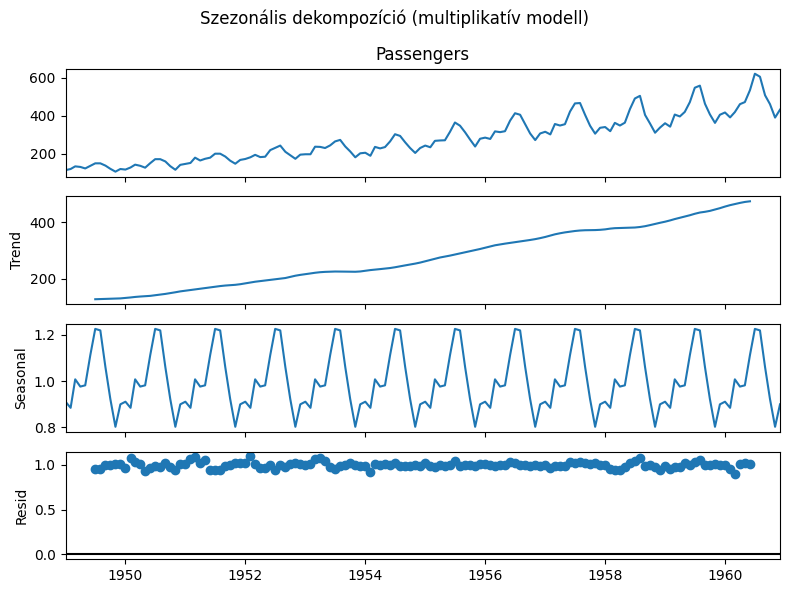

In [304]:
## Az airline-passengers dataset dekompozíciója

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Adat betöltése
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Multiplikatív szezonális dekompozíció (havi adatoknál period=12)
result = seasonal_decompose(df['Passengers'], model='multiplicative', period=12)

# Eredmények vizualizálása
plt.rcParams.update({'figure.figsize': (8, 6)})
result.plot()
plt.suptitle("Szezonális dekompozíció (multiplikatív modell)")
plt.tight_layout()
plt.show()


<strong> Mit látunk a diagramon?</strong> 

A dekompozíció négy részből áll:

1. **Eredeti idősor (Original):**  
   Az utasforgalom eredeti alakulása időben.

2. **Trend komponens:**  
   A hosszú távú növekedés – az utasszám évről évre egyre magasabb.

3. **Szezonális komponens:**  
   Az évszakos ismétlődés – minden évben nyáron van a csúcs, télen visszaesés.

4. **Reziduális (Remainder) komponens:**  
   A maradék zaj, amit a trend és szezonalitás nem magyaráz.  
   Ezek a kisebb véletlenszerű kilengések, például különleges események hatása.

<div style="background-color:#f5f0ff; border-left:6px solid #a855f7; padding:12px; border-radius:8px;">
<b><strong>Összegzés:</strong></b><br>

- A szezonalitás és trend elkülönítése segít abban, hogy a későbbiekben pontosabb előrejelzéseket készítsünk,  
- például ARIMA vagy gépi tanulási modellek segítségével.
</div>




#### 3.1. Mikor legyen Additív és mikor Multiplikatív modell?

A szezonalitás formája attól függ, **hogyan változik az ingadozás mértéke** az idősor értékeivel együtt.

<strong>Additív szezonalitás</strong>
- A **szezonális ingadozás nagysága állandó**, függetlenül attól, mekkora az alapszint (trend).  
- Más szóval: a különbség a csúcs és a völgy között **mindig hasonló**.  
- A **trend és a szezonalitás összeadódik**:  
  $$
  Y_t = Trend_t + Szezonális_t + Reziduum_t
  $$

<div style="background-color:#e8fbe8; border-left:6px solid #16a34a; padding:12px; border-radius:8px;">
<b><strong>Példa:</strong></b><br>

- napi átlaghőmérséklet egy városban – a szezonális különbség (pl. 10–15°C) évek múlva is hasonló marad, még ha az éghajlat lassan melegszik is.
</div>

A bal oldali ábrán látható, hogy a hullámok amplitúdója (az eltérés nagysága) az idő múlásával nem változik.



<strong> Multiplikatív szezonalitás </strong>
- A **szezonális ingadozás mértéke arányos az idősor értékével**.  
- Ahogy nő a trend, úgy **nő a kilengések nagysága** is.  
- A **komponensek szorzódnak**:  
  $$
  Y_t = Trend_t \times Szezonális_t \times Reziduum_t
  $$

<div style="background-color:#e8fbe8; border-left:6px solid #16a34a; padding:12px; border-radius:8px;">
<b><strong>Példa:</strong></b><br>

- havi eladások vagy utasszám – ha nő az összforgalom, a szezonalitás (pl. nyári csúcs) is arányosan nagyobb lesz.
</div>


A jobb oldali ábrán megfigyelhető, hogy a szezonalitás hullámai egyre nagyobbak: a kilengés nem állandó, hanem nő a forgalommal együtt.

<div style="text-align:center;">
  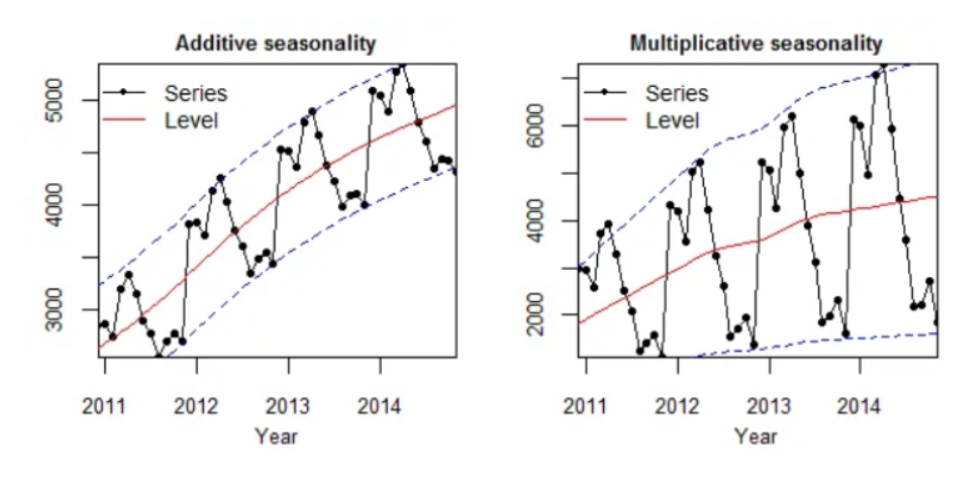
  <p style="font-style:italic; color:gray; margin-top:6px;">
    3. ábra. – Additív és multiplikatív szezonalitás 
  </p>
</div>



<strong> Hogyan döntsd el, melyiket válaszd?</strong> 

- Ha az adatsor **körülbelül azonos mértékben ingadozik** az idő folyamán → **Additív modell**  
- Ha a **kilengések az érték növekedésével arányosan nőnek** → **Multiplikatív modell**


<div style="background-color:#f5f0ff; border-left:6px solid #a855f7; padding:12px; border-radius:8px;">
<b>Tipp:</b><br>
Vizualizáld az idősorodat! Ha a grafikonon az ingadozások (hullámok) <strong> erősödnek az idővel</strong>, a multiplikatív modell a jobb választás.</div>
</div>  


#### 3.2. Szezonális mintázat felismerése (vizuálisan és statisztikusan)

Az idősorokban gyakran előfordulnak **ismétlődő minták** — például minden nyáron nő az eladás,  
vagy minden télen visszaesik a kereslet.  
Ezeket a **szezonális ciklusokat** (seasonality) az egyik legkönnyebben vizuálisan azonosíthatjuk.


<strong>Miért fontos a szezonalitás felismerése?</strong>

- A szezonalitás segít **előrejelzéseket pontosítani** (pl. mikor várható csúcs vagy visszaesés).  
- Lehetővé teszi az adatok **normalizálását** (pl. az évszakok hatásának kiszűrését).  
- Segít **anomáliákat** felismerni: ha egy hónap értéke kilóg a megszokott tartományból.



<strong>Hogyan vizsgáljuk a szezonalitást?</strong>

1. **Csoportosítsuk** az adatokat hónapokra (1–12).  
2. **Boxplotot** (dobozdiagramot) készítünk, amely megmutatja az egyes hónapok értékeinek eloszlását.  
3. Az így kapott ábrán látható, mely hónapokban jellemzően magasabb vagy alacsonyabb az utasszám.



<Axes: title={'center': 'Passengers'}, xlabel='month'>

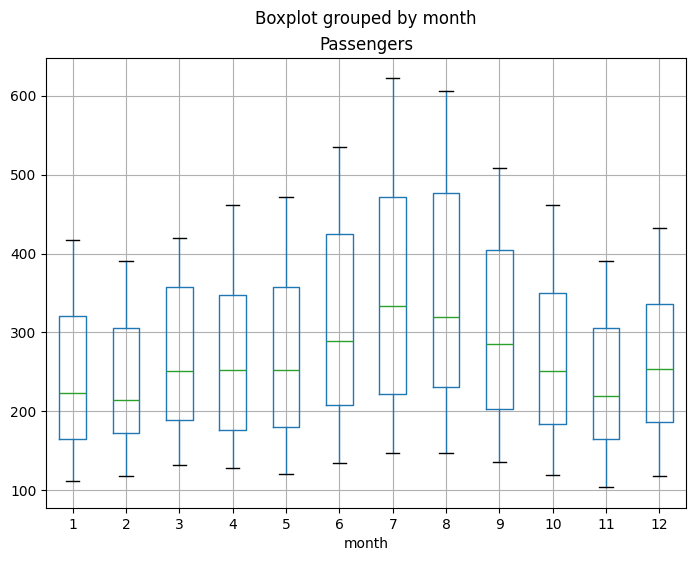

In [312]:
df['month'] = df.index.month
df.boxplot(column='Passengers', by='month')


### 4. Hasonlóság alapú keresés az Airline dataset szegmensein

Ahogyan bármely más adattípusnál, az **idősorok elemein** is végezhetünk **hasonlósági vizsgálatot**.  
Ez különösen hasznos, ha szeretnénk:
- visszatérő **mintákat** vagy **viselkedésmintákat** azonosítani (pl. hasonló növekedési ciklusokat),
- vagy épp **anomáliákat** keresni, amelyek eltérnek a megszokott trendtől.

<strong> Mi a hasonlóság alapú keresés lényege?</strong>

Ahelyett, hogy az egész idősorra tekintenénk, **kisebb szegmensekre** bontjuk azt, majd megvizsgáljuk, hogy az egyes szegmensek **mennyire hasonlítanak egymásra**.  

Ha például:
- egy adott időszakban **szokatlan viselkedést** látunk (pl. kiugró érték, hirtelen esés vagy emelkedés), akkor ezt a „mintát” (vagy „anomalikus ablakot”) végiggörgetve az idősoron **megkereshetjük**,hogy előfordult-e **hasonló minta** korábban.


<div style="background-color:#e8fbe8; border-left:6px solid #16a34a; padding:12px; border-radius:8px;">
<b>Például:</b><br>
Gondolj az autó motorjára:<br>
Ha az autód motorja egy hétig furcsán rezgett, akkor megfigyelheted a jövőben, mikor <strong>ismét jelentkezik ugyanez a rezgésminta</strong>.  
Ugyanígy működik az idősor-hasonlóság is: egy anomáliás időszakot végiggörgetünk az adaton, és <strong>hasonló viselkedésű szakaszokat</strong> keresünk.
</div>
<br>

<strong>Hogyan mérjük a hasonlóságot?</strong>

Az idősor-szegmensek összehasonlításához különböző metrikákat használhatunk:
- **Cosine similarity** – azt méri, mennyire azonos irányú a két minta (függetlenül a nagyságtól).  
- **Euclidean distance** – a két minta közötti távolságot számolja (nagyságérzékeny).  
- **Dynamic Time Warping (DTW)** – akkor is jól működik, ha az idősor szegmensek „elcsúsznak” egymáshoz képest időben.

Ebben a példában a **cosine similarity** segítségével vizsgáljuk, hogy az *Airline passengers* adathalmazban találhatók-e **hasonló trendű időszakok**.




In [315]:
from sklearn.metrics.pairwise import cosine_similarity

# Vegyünk ki 3 év 12 hónapját külön vektorként
year1 = df['1949-01':'1949-12']['Passengers'].values.reshape(1, -1)
year2 = df['1950-01':'1950-12']['Passengers'].values.reshape(1, -1)
year3 = df['1951-01':'1951-12']['Passengers'].values.reshape(1, -1)

# Koszinusz-hasonlóság
cosine_similarity(year1, year2)  # érték 0 és 1 között


array([[0.99896855]])

<div style="background-color:#f5f0ff; border-left:6px solid #a855f7; padding:12px; border-radius:8px;">
<b>Fontos:</b><br>
A koszinusz hasonlóságról még az előző órán tanultunk, igy ennek magyarázatától eltekintünk. 
</div>

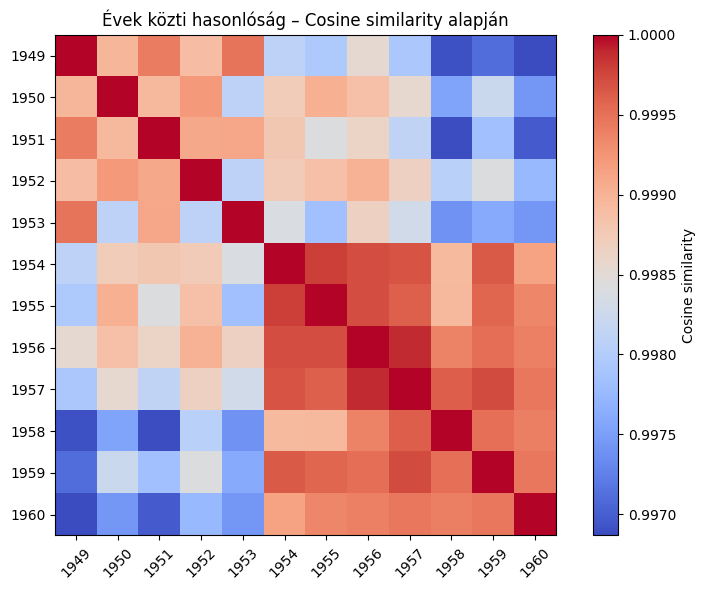

In [318]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Airline dataset betöltése
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Éves bontás
years = df.index.year.unique()
yearly_data = {}

for year in years:
    data = df[df.index.year == year]['Passengers']
    if len(data) == 12:  # csak teljes évek
        yearly_data[year] = data.values

# Évek listája és vektorok mátrixban
year_labels = list(yearly_data.keys())
year_vectors = np.array([yearly_data[year] for year in year_labels])

# Koszinusz hasonlóság számítása
cos_sim = cosine_similarity(year_vectors)

# Ábra: hőtérkép (heatmap)
plt.figure(figsize=(8, 6))
plt.imshow(cos_sim, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Cosine similarity')
plt.xticks(ticks=np.arange(len(year_labels)), labels=year_labels, rotation=45)
plt.yticks(ticks=np.arange(len(year_labels)), labels=year_labels)
plt.title("Évek közti hasonlóság – Cosine similarity alapján")
plt.tight_layout()
plt.show()


Ez az ábra egy hőtérkép (heatmap), amely azt mutatja meg, hogy az egyes évek mennyire hasonlítanak egymásra az utasszám havi alakulása alapján – cosine similarity módszerrel mérve.

<strong>A megoldás nem tökéletes</strong>

A **koszinusz-hasonlóság (cosine similarity)** nagyon hasznos, ha az idősorok:
- **egyenlő hosszúságúak**,  
- **szinkronban vannak egymással**,  
- és a mintázatuk csak **skálában** tér el (például az egyik kicsit nagyobb értékeket vesz fel).

Viszont van egy fontos korlátja:
- A cosine similarity csak az **egymáshoz pontosan igazított** mintákat tudja jól összehasonlítani.

Ha a két idősor hasonló alakú, de az egyik **kicsit eltolódott az időben** (pl. a csúcs egy héttel később következik be), akkor a koszinusz-hasonlóság már **nem fogja felismerni** őket hasonlónak — hiába „ugyanaz a történet”, csak időben elcsúszva.


<div style="background-color:#e8fbe8; border-left:6px solid #16a34a; padding:12px; border-radius:8px;">
<b><strong>Példa:</strong></b><br>

Képzeljük el, hogy két város napi hőmérsékletét hasonlítjuk:
- az egyik városban a kánikula **július 10-én** kezdődik,
- a másikban **július 13-án**.

A görbék alakja ugyanaz, csak **három napot csúsznak** egymáshoz képest — a cosine similarity viszont ezt a kapcsolatot **nem ismeri fel**.

</div>

<br>
<strong> A megoldás: DTW (Dynamic Time Warping)</strong>
<br>
<br>

A **DTW** egy fejlettebb hasonlósági mérőszám, amely:
- **képes kezelni időbeli eltolásokat**,  
- rugalmasan **„nyújtja vagy húzza”** az idősorokat, hogy a hasonló minták egymásra illeszthetők legyenek,
- így a **„fáziseltolódás”** már nem jelent problémát.

Másképp fogalmazva:
- A DTW nemcsak azt nézi, *mekkora az eltérés az értékekben*,  
- hanem azt is, *hogyan igazíthatók egymáshoz időben*.


#### További olvasnivaló

A módszert részletesen ismerteti a tslearn könyvtár dokumentációja:  
[DTW – Dynamic Time Warping (tslearn)](https://tslearn.readthedocs.io/en/stable/user_guide/dtw.html)


<div style="background-color:#f5f0ff; border-left:6px solid #a855f7; padding:12px; border-radius:8px;">
<b>Összegzés:</b><br>

| Módszer | Előnye | Hátránya |
|----------|---------|-----------|
| **Cosine Similarity** | Gyors, egyszerű, jól működik, ha az idősorok pontosan igazítottak | Nem kezeli az időbeli eltolást |
| **DTW (Dynamic Time Warping)** | Felismeri az időben elcsúszott, de hasonló mintákat | Lassabb, bonyolultabb, és számításigényesebb |

Összességében: ha két idősor hasonló alakú, de nem pontosan szinkronban vannak, a **DTW sokkal pontosabban méri a valós hasonlóságot**.
</div>





### 5. Cross-correlation két év havi mintája között

A **keresztkorreláció (cross-correlation)** azt méri, hogy **két idősor mennyire hasonlít egymásra**, ha az egyiket időben **eltoljuk** a másikhoz képest.  
Ez segít felismerni, hogy az egyik változó **megelőzi, követi vagy egyidejű** a másikkal.


<strong> Példa – két év összehasonlítása</strong>

Tegyük fel, hogy az **1957-es** és **1958-as** évek utasforgalmát szeretnénk összevetni az *Airline passengers* adathalmazból.  
A cél: megnézni, vajon az 1958-as év **ugyanazt a mintát** követi, mint az előző év – esetleg **néhány hónapos eltolással**.

Ezzel a módszerrel megérthetjük:
- hogy az utasszámok szezonális csúcsa (pl. nyári hónapok) **pontosan mikor** jelentkezik,
- és hogy az egyik év **megelőzi-e** a másikat (pl. a csúcsidő korábban vagy később jött).



<strong> Mit csinál a keresztkorreláció?</strong>

1. **Kiválasztunk két idősor-szegmenst** (itt: 1957 és 1958 havi utasszámok).  
2. Az egyik szegmenst **eltoljuk** pozitív és negatív irányban (±lag értékek).  
3. Minden eltolásnál kiszámítjuk, mennyire hasonlítanak egymásra a két minta értékei.  
4. Az így kapott korrelációs értékeket ábrázoljuk az eltolás (lag) függvényében.



<strong>Hogyan értelmezzük az eredményt? </strong>

- A **legmagasabb korrelációs csúcs** mutatja, hogy milyen eltolással hasonlítanak legjobban a minták.  
- Ha a csúcs **lag = 0**-nál van → a két év mintázata **szinkronban** van.  
- Ha a csúcs **pozitív lag**-nál → az első év **megelőzi** a másodikat.  
- Ha a csúcs **negatív lag**-nál → az első év **késik** a másodikhoz képest.



<strong> Példa vizualizációra</strong>

Az alábbi ábra azt mutatja, hogyan változik a korreláció az eltolás függvényében.  
A `stem` diagram minden eltolási értékhez (lag) megmutatja, mekkora a kapcsolat erőssége a két év között.

A legmagasabb pont jelzi, **melyik eltolás mellett** a legerősebb a hasonlóság.


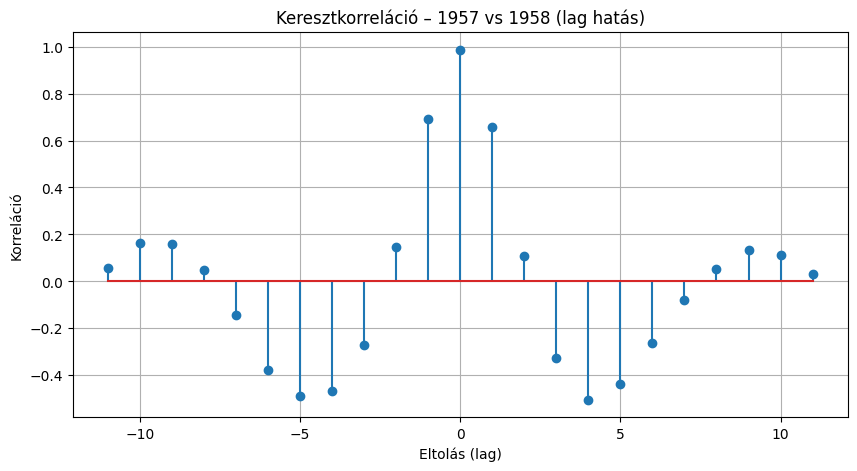

In [323]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Adat betöltés
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv")
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Két év kiválasztása (csak ha mindkettő 12 hónap!)
year1 = df[df.index.year == 1957]['Passengers'].values
year2 = df[df.index.year == 1958]['Passengers'].values

# Keresztkorreláció számítása (-11, ..., 0, ..., +11 lag értékek)
corr = np.correlate(year1 - np.mean(year1), year2 - np.mean(year2), mode='full')
lags = np.arange(-len(year1) + 1, len(year2))

# Normalizálás
corr = corr / (np.std(year1) * np.std(year2) * len(year1))

# Ábra
plt.figure(figsize=(10, 5))
plt.stem(lags, corr)
plt.title("Keresztkorreláció – 1957 vs 1958 (lag hatás)")
plt.xlabel("Eltolás (lag)")
plt.ylabel("Korreláció")
plt.grid(True)
plt.show()


<strong>Mit látunk a keresztkorrelációs ábrán?</strong>

Az ábrán az **x-tengely** az eltolást (**lag**, vagyis késleltetés) mutatja,az **y-tengely** pedig a két év közötti **korreláció mértékét**.  
A korreláció azt mutatja meg, hogy az egyik idősor mennyire hasonlít a másikra,ha az egyik sor időben előre vagy hátra van csúsztatva.



<strong>Alapértelmezett értelmezés</strong>

- **Lag = 0** → Azonos időpontok összehasonlítása.  
  A korreláció értéke itt azt mutatja, mennyire hasonló az 1957-es és az 1958-as év mintázata hónapról hónapra.  
  Itt a korreláció **közel 1**, vagyis a két év **nagyon hasonló** trendet követett.

- **Lag > 0** → Az első sor (1957) **megelőzi** a másodikat.  
  Más szóval: az 1957-es csúcsidőszak **korábban következett be**.  
  Ha itt magas korrelációs értéket látnánk, az arra utalna, hogy a következő év viselkedése késve ismétli a korábbit.

- **Lag < 0** → Az első sor (1957) **késik** a másodikhoz képest.  
  Ez akkor fordulna elő, ha az 1958-as szezonális csúcsok **korábban** jönnének el, mint az előző évben.



<strong> Mit látunk konkrétan ezen az ábrán?</strong>

- A legnagyobb korreláció **lag = 0**-nál található → az 1958-as év mintázata **nagyon szorosan követi** az 1957-es év viselkedését,tehát a szezonalitás **stabil és ismétlődő** évről évre.

- A **pozitív és negatív lag értékeknél** a korreláció fokozatosan csökken,ami azt jelenti, hogy ha az idősorokat eltoljuk, a minták **kevésbé fedik egymást**.

- A **negatív korrelációs zónák** (pl. ±5 hónap körül) azt mutatják,hogy ha az egyik év csúcspontját a másik völgyével hasonlítjuk,  
  akkor az értékek ellentétes irányban mozognak (tehát amikor az egyikben növekedés van, a másikban csökkenés).

<div style="background-color:#f5f0ff; border-left:6px solid #a855f7; padding:12px; border-radius:8px;">
<b>Összegzés:</b><br><br>

Ez az ábra megerősíti, hogy:<br>
- az *Airline passengers* idősor **nagyon stabil szezonális mintázatot** mutat,  
- az **évek közötti ciklusok** szinte azonos időpontokban ismétlődnek,  
- a **lag = 0** körüli erős korreláció a **szezonális konzisztenciát** jelzi.

Ebből következik, hogy az adatsor előrejelzéséhez (forecasting) jól alkalmazhatók a **szezonalitást kihasználó modellek** (pl. SARIMA, Prophet, stb.).

</div>



### 6. Vizuális idősor-térkép (Heatmap)

A **vizuális idősor-térkép**, vagy más néven **heatmap**, az egyik leghatékonyabb módja annak,  
hogy egyszerre lássuk az **éves trendeket** és a **havi szezonalitást** egy idősoron belül.

Az ötlet egyszerű:  
az egyes **éveket** egymás mellé helyezzük (oszlopokként),  
a **hónapokat** pedig függőlegesen jelenítjük meg (sorokként).  
Így a színek segítségével azonnal kirajzolódik, mikor voltak a **legforgalmasabb** és **leggyengébb** időszakok.



<strong> Miért hasznos ez a megjelenítés?</strong>

- **Szezonalitás felismerése:** az ismétlődő mintázatok (pl. minden évben a nyári hónapokban növekedés) könnyen láthatók.  
- **Trend vizsgálata:** az évek előrehaladtával a színek árnyalata változik (világosabb → sötétebb = növekedés).  
- **Anomáliák azonosítása:** ha egy adott hónap szokatlanul eltér a környező értékektől, az színben is azonnal feltűnik.



<strong> Hogyan készül a hőtérkép?</strong>

1. **Csoportosítjuk az adatokat évekre** (`Grouper(freq='A')`)  
2. **Kinyerjük a havi értékeket** minden évhez, és egy új táblázatot készítünk,  
   ahol minden oszlop egy év, a sorok pedig a hónapok.  
3. **Matplotlib `imshow()` függvényével** hőtérképet rajzolunk,  
   ahol a színek a havi utasszámokat mutatják.



<strong>Mit látunk a grafikonon?</strong>

- A **x-tengely** az éveket mutatja (1949–1960).  
- Az **y-tengely** a hónapokat (1–12).  
- A színek az **utasszám intenzitását** jelzik:  
  - világos → alacsony forgalom (pl. téli hónapok),  
  - sötét → magas forgalom (pl. nyári csúcsidőszak).  

A grafikonból jól látható, hogy:
- Minden évben **nyáron** van az utasszám csúcsa (július–augusztus),  
- Az **évek előrehaladtával** az egész színskála eltolódik felfelé (az utasszám folyamatosan nő),  
- A **mintázat évről évre szinte azonos**, ami erős **szezonalitást** jelez.  

<div style="background-color:#e8fbe8; border-left:6px solid #16a34a; padding:12px; border-radius:8px;">
<b><strong>Érdekesség:</strong></b><br>

- Ha egy év kilóg a többi közül (pl. sápadtabb vagy sokkal sötétebb hónapok),az gyakran gazdasági eseményre, adatgyűjtési hibára vagy külső hatásra utalhat.
</div>
 



C:\Users\koros\AppData\Local\Temp\ipykernel_45148\3596192403.py:11: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  groups = df.groupby(Grouper(freq='A'))     # 'A' = Annual (éves csoportosítás)
C:\Users\koros\AppData\Local\Temp\ipykernel_45148\3596192403.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1000x600 with 0 Axes>

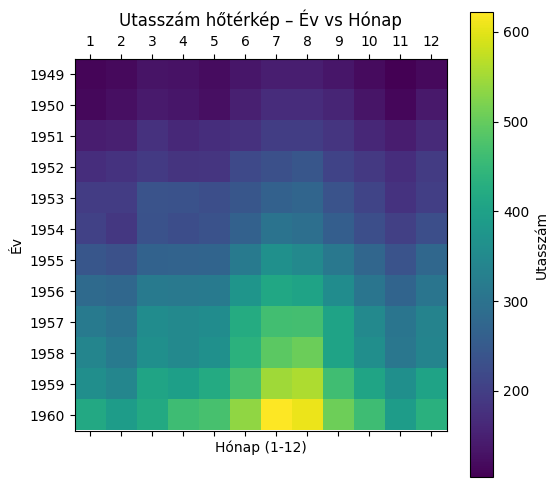

In [327]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas import Grouper, DataFrame

# 1. Adat betöltése
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv")
df['Month'] = pd.to_datetime(df['Month'])  # dátumként értelmezzük
df.set_index('Month', inplace=True)        # dátum legyen az index

# 2. Adatok csoportosítása évenként
groups = df.groupby(Grouper(freq='A'))     # 'A' = Annual (éves csoportosítás)

# 3. Új DataFrame, ahol minden oszlop egy év havi értékeit tartalmazza
years = DataFrame()
for name, group in groups:
    years[name.year] = group['Passengers'].values  # hónapok sorok, évek oszlopok

# 4. Hőtérkép (heatmap) készítése
plt.figure(figsize=(10, 6))
plt.matshow(years.T, interpolation=None)
plt.title("Utasszám hőtérkép – Év vs Hónap")
plt.xlabel("Hónap (1-12)")
plt.ylabel("Év")
plt.xticks(ticks=range(12), labels=range(1, 13))                   # hónapok (1-12)
plt.yticks(ticks=range(len(years.columns)), labels=years.columns)  # évek
plt.colorbar(label="Utasszám")
plt.tight_layout()
plt.show()


### 7. KDE plot az Airline dataset utasszámaira

A KDE (Kernel Density Estimation) ábra az utasszámok **eloszlását** mutatja. Segítségével láthatjuk, hogy mely értéktartományokban fordult elő leggyakrabban az utasszám.  
Az eloszlás egyértelműen **jobbra tolódott**, ami az évek során növekvő utasforgalmat jelez.



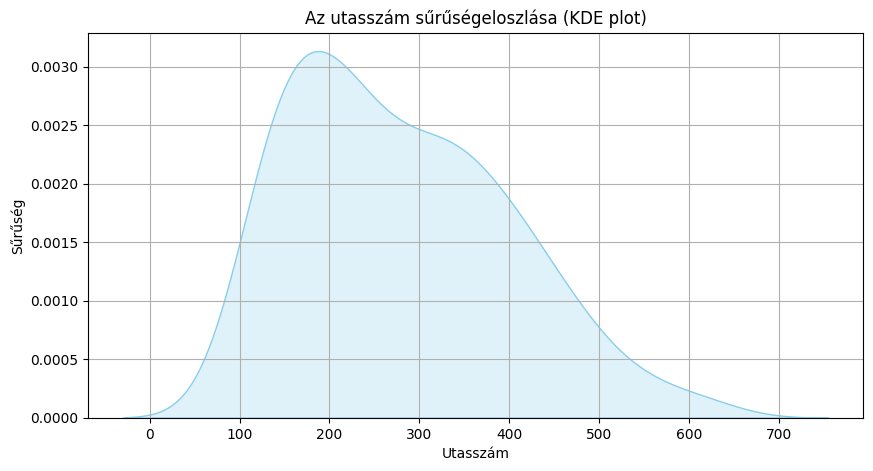

In [330]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Adat betöltése
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv")
df['Month'] = pd.to_datetime(df['Month'])
df['Year'] = df['Month'].dt.year

# KDE plot – az összes utasszám eloszlása
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='Passengers', fill=True, color="skyblue")
plt.title("Az utasszám sűrűségeloszlása (KDE plot)")
plt.xlabel("Utasszám")
plt.ylabel("Sűrűség")
plt.grid(True)
plt.show()



### 8. KDE több évre bontva

Ebben az ábrában az utasszámok **évenkénti sűrűségeloszlása** látható.  
Minden szín egy adott évet jelöl, így jól megfigyelhető, hogyan **tolódik el az eloszlás** évről évre a nagyobb utasszámok irányába — azaz az utasforgalom folyamatosan nőtt az időszak során.


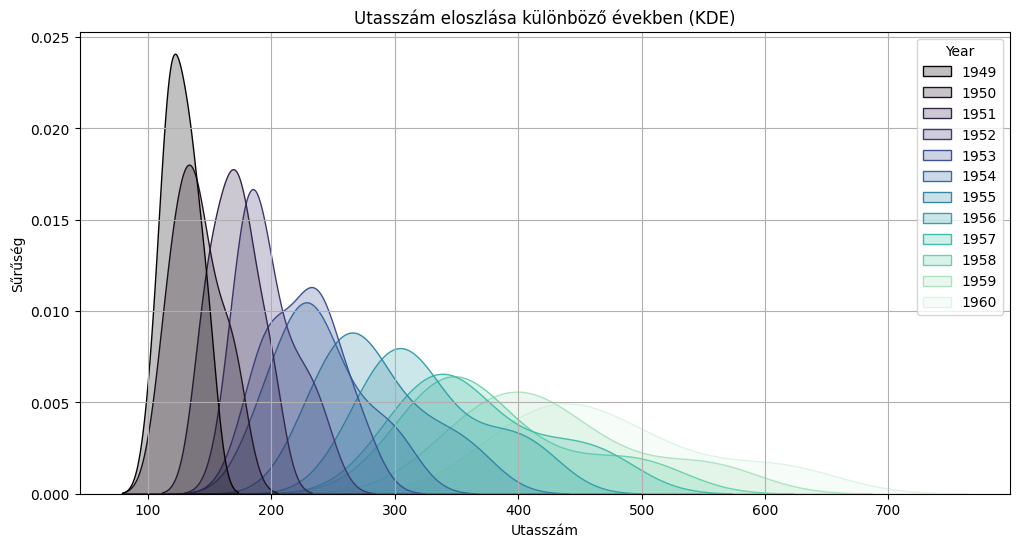

In [333]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x='Passengers', hue='Year', fill=True, common_norm=False, palette='mako')
plt.title("Utasszám eloszlása különböző években (KDE)")
plt.xlabel("Utasszám")
plt.ylabel("Sűrűség")
plt.grid(True)
plt.show()


<strong> Mit látunk?</strong>

Az ábrán az utasszámok **évenkénti eloszlását (KDE)** látjuk.  
Jól látszik, hogy az évek előrehaladtával az eloszlás **egyre jobbra tolódik** – azaz az utasszámok fokozatosan növekednek.  
Ugyanakkor az eloszlások **nem szimmetrikusak**, hanem **jobbra ferde (skewed)** eloszlást mutatnak.

<strong>Értelmezés:</strong>
- A **ferdeség (skewness)** azt jelzi, hogy sok kisebb érték és néhány nagyon nagy érték torzítja az átlagot.  
- Ez a torzulás problémát jelenthet a **lineáris regressziós és ARIMA modellek** számára, mivel azok a normalitást feltételezik.
- Az ilyen típusú adatok **nem normális eloszlásúak**, ezért gyakran érdemes **logaritmikus (LOG)** vagy **Box-Cox transzformációt** alkalmazni az adatok kiegyensúlyozására.

<strong> Javaslat:</strong>
A **LOG-transzformáció** segít közelíteni az adatokat a normáleloszláshoz, így a modellek stabilabbak és pontosabbak lesznek.

Bővebben a transzformációról:  
[Box–Cox transzformáció Pythonban – GeeksforGeeks](https://www.geeksforgeeks.org/box-cox-transformation-using-python/)


### 9. 2D KDE – Hónap és utasszám kapcsolata

A kétdimenziós KDE (bivariate KDE) ábra megmutatja, **mely hónapokban** volt a legnagyobb az utasforgalom.  
A színek a sűrűséget jelzik: a **melegebb színek (rózsaszín–piros)** nagyobb utasszámot és sűrűbb előfordulást mutatnak.  

<strong>Értelmezés:</strong>
- A nyári hónapok (6–8) környékén a legnagyobb az utasszám – ez jelzi a szezonális hatást.  
- A téli hónapokban (1–2 és 11–12) az utasszám alacsonyabb, kevesebb repülőút történik.  
- Az eloszlás formája jól mutatja az **éves ciklikusságot** az utasforgalomban.


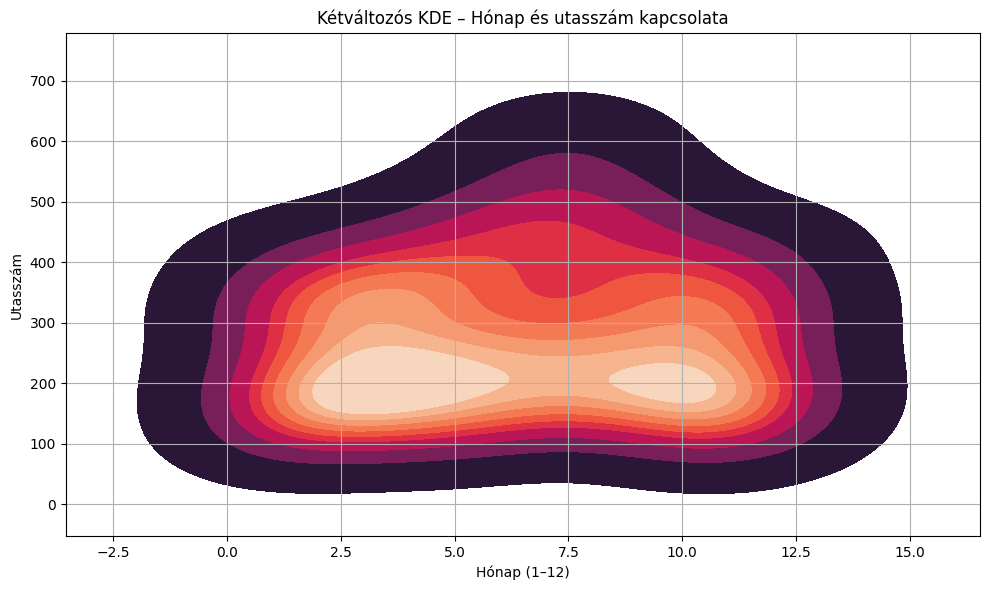

In [337]:
### 2D KDE (bivariate KDE) – hónap vs utasszám

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 📥 Adat betöltés
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv")
df['Month'] = pd.to_datetime(df['Month'])
df['month_num'] = df['Month'].dt.month  # numerikus hónap (1-12)

# 📈 Bivariate KDE plot: hónap vs utasszám
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df,
    x='month_num',
    y='Passengers',
    cmap="rocket",
    fill=True,
    thresh=0.02
)
plt.title("Kétváltozós KDE – Hónap és utasszám kapcsolata")
plt.xlabel("Hónap (1–12)")
plt.ylabel("Utasszám")
plt.grid(True)
plt.tight_layout()
plt.show()


<strong>Mit látunk ezen az ábrán?</strong>
- Ahol a szín sötétebb, ott sűrűbben fordulnak elő az adott hónap–utasszám párosok.

<strong>Például:</strong>
- Hónap: 7–8
- Utasszám: 400–600 → nyári csúcs jól kirajzolódik.

### 10. Bivariate KDE több évre bontva

Ebben az ábrában a **hónap–utasszám kapcsolat** évenként van külön megjelenítve.  
Minden év egy külön KDE-plotot kapott, így **külön vizsgálható, hogyan változott az utazási szezonális minta az évek során**.

**Mit figyelhetünk meg:**
- A mintázat **évről évre hasonló** – a csúcs mindig a nyári hónapokban (június–augusztus) jelentkezik.  
- Ugyanakkor az eloszlás **folyamatosan tolódik felfelé**, vagyis évről évre egyre nagyobb utasszámokat látunk.  
- A KDE formája mutatja a **szezonális stabilitást**, míg az eltolódás a **trend növekedését** jelzi.

Ez az ábra jól szemlélteti, hogy **az idősor nemcsak ismétlődő (szezonális)**, hanem **trendkomponenst is tartalmaz**.


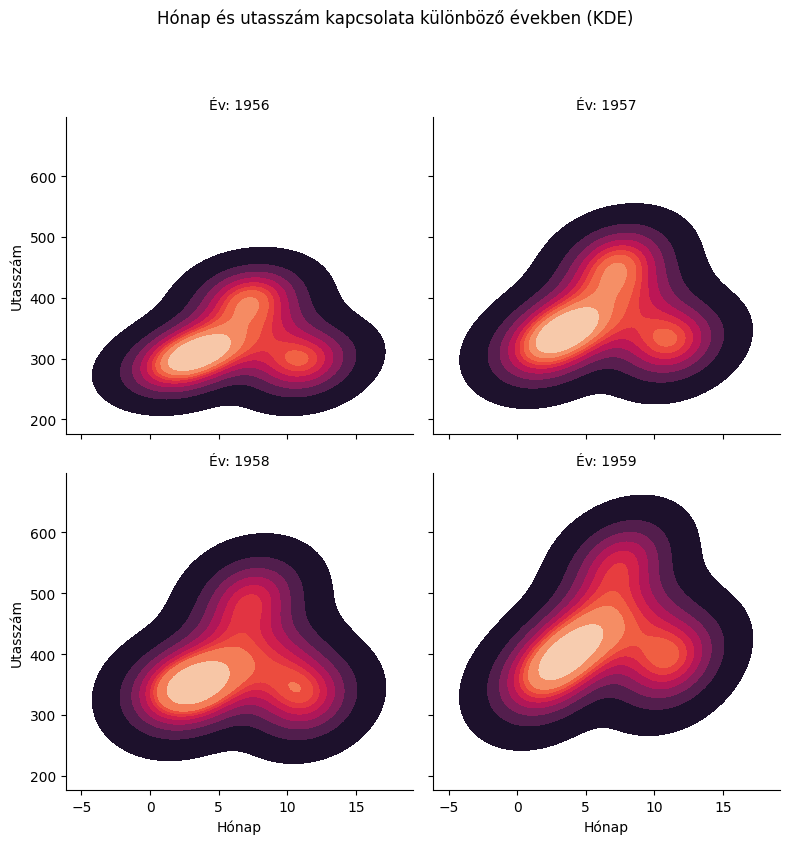

In [341]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 📥 Adat betöltés
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv")
df['Month'] = pd.to_datetime(df['Month'])
df['Year'] = df['Month'].dt.year
df['month_num'] = df['Month'].dt.month

# 🔍 Csak 3-4 év kiválasztása, hogy ne legyen túlzsúfolt a plot
df_sample = df[df['Year'].isin([1956, 1957, 1958, 1959])]

# 📈 Faceted bivariate KDE – külön ábra minden évre
g = sns.FacetGrid(df_sample, col="Year", col_wrap=2, height=4)
g.map_dataframe(
    sns.kdeplot,
    x="month_num",
    y="Passengers",
    fill=True,
    cmap="rocket",
    thresh=0.02
)
g.set_titles("Év: {col_name}")
g.set_axis_labels("Hónap", "Utasszám")
plt.suptitle("Hónap és utasszám kapcsolata különböző években (KDE)", y=1.05)
plt.tight_layout()
plt.show()


### 11. Évenkénti standardizálás + KDE

Ebben a lépésben az utasszámokat **évenként standardizáljuk**, vagyis minden évben levonjuk az adott év átlagát, és elosztjuk a szórásával.  
Ezt nevezzük **z-score normalizálásnak**, ami segít az évek közti különbségek kiegyenlítésében.

**Mit jelent ez?**
- Az egyes évek adatai **összehasonlíthatóvá válnak**: minden évben az átlag 0, a szórás pedig 1 lesz.  
- Így nem a trend vagy az abszolút növekedés számít, hanem az, **mely hónapok térnek el az adott év átlagától**.  
- A KDE görbék ezért **a szezonális mintát** mutatják torzítás nélkül — az abszolút utasszám növekedés már nem befolyásolja őket.

Ez a módszer különösen hasznos, ha **a szezonális hatásokat** akarjuk látni **trendmentesített formában**.


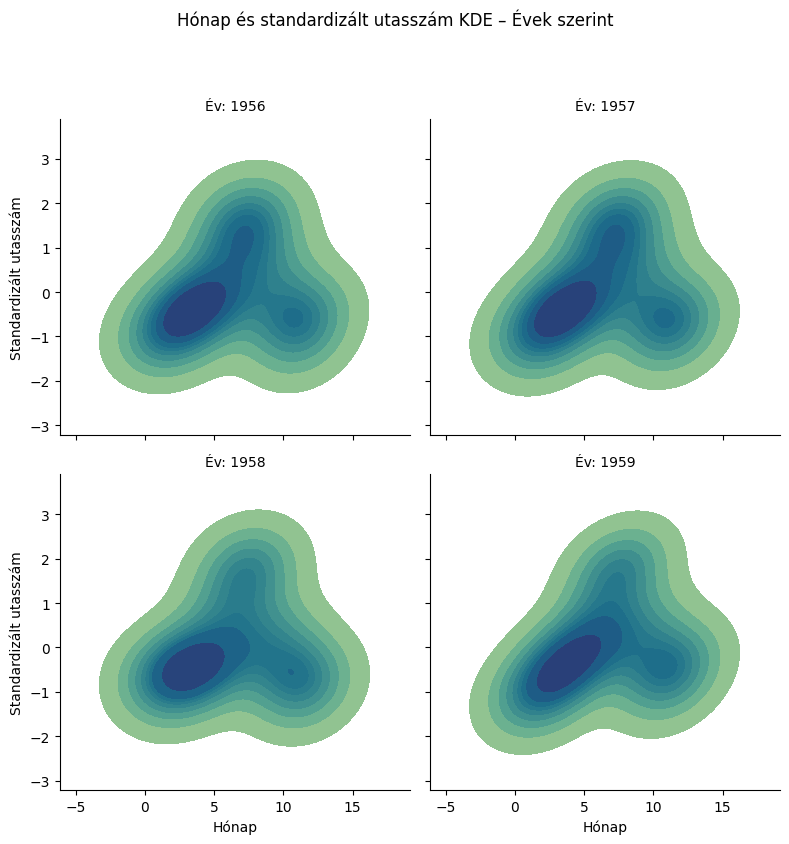

In [344]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Adat betöltése
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv")
df['Month'] = pd.to_datetime(df['Month'])
df['Year'] = df['Month'].dt.year
df['month_num'] = df['Month'].dt.month

# Standardizáljuk az utasszámokat évenként (z-score: (x - mean)/std)
df['Passengers_std'] = df.groupby('Year')['Passengers'].transform(
    lambda x: (x - x.mean()) / x.std()
)

# Válasszunk ki néhány év plotolásra
df_sample = df[df['Year'].isin([1956, 1957, 1958, 1959])]

# KDE plot évenként külön (facet)
g = sns.FacetGrid(df_sample, col="Year", col_wrap=2, height=4)
g.map_dataframe(
    sns.kdeplot,
    x="month_num",
    y="Passengers_std",
    fill=True,
    cmap="crest",
    thresh=0.05
)
g.set_titles("Év: {col_name}")
g.set_axis_labels("Hónap", "Standardizált utasszám")
plt.suptitle("Hónap és standardizált utasszám KDE – Évek szerint", y=1.05)
plt.tight_layout()
plt.show()


<strong>Mit látunk az ábrákon?</strong>

- Standardizált utasszám: 0 = éves átlag, pozitív = hónap erősebb az átlagnál, negatív = gyengébb.
- Ha pl. 1959 nyara világosabb → nyári hónapok jelentősen meghaladták az éves átlagot.
- Így nem a mennyiség, hanem a viselkedés különbségei látszanak.

### 12. Előrejelezhetőség – mikor tudunk „a jövőbe látni”?

A kurzus témája **adatbányászat** – az adatokban rejlő **minták, szabályszerűségek és összefüggések** feltárása. Nem kifejezetten **forecast (előrejelző) modellek** építésével foglalkozunk, de bizonyos esetekben, például **trendek vagy ciklusok azonosításakor**, az előrejelezhetőség kérdése **mégis fontos** lehet.


<strong> Mi az előrejelezhetőség kulcsa?</strong>

Egy idősor akkor **előrejelezhető**, ha **tartalmaz valamiféle szerkezetet** – vagyis a múltbeli viselkedés alapján következtethetünk a jövőre.

Egy jól modellezhető idősor általában rendelkezik:

- **Trendekkel** – például hosszú távú növekedéssel vagy csökkenéssel *(pl. évről évre nő az utasforgalom vagy a bevétel)*  
- **Szezonális hatásokkal** – ismétlődő mintázatokkal *(pl. nyáron több turista, télen kevesebb eladás)*  
-  **Autokorrelációval** – amikor az aktuális értékek **kapcsolatban vannak a korábbiakkal** *(ha ma sok az utas, valószínűleg holnap is több lesz)*


<strong> Mikor nem érdemes előrejelezni?</strong>

Ha az idősor nem tartalmaz semmilyen mintát, csak **véletlenszerű ingadozást (fehér zaj)** vagy **véletlen bolyongást (random walk)**, akkor a múltbeli értékek **nem segítenek a jövő becslésében**.

- Ilyenkor az előrejelzés vagy **értelmetlen**, vagy **csak nagyon rövid távon** működhet.
- Például a napi részvényárfolyamoknál a következő lépés szinte teljesen véletlenszerű.

<div style="background-color:#f5f0ff; border-left:6px solid #a855f7; padding:12px; border-radius:8px;">
<b>Összefoglalás:</b><br>

| Típus | Példa | Előrejelezhető? |
|-------|--------|----------------|
| **Trend + szezonalitás + autokorreláció** | Éves eladások, havi utasforgalom | ✅ Igen |
| **Csak trend** | Folyamatos növekedés, lassú csökkenés | ⚠️ Rövid távon igen |
| **Fehér zaj** | Véletlen hőmérsékletingadozás | ❌ Nem |
| **Random walk** | Tőzsdei árfolyam | ❌ Csak rövid távon, korlátozottan |
</div>






#### 12.1. White Noise (Fehér zaj)

A **fehér zaj** egy olyan idősor, amelyben **nincs semmilyen szabályosság, trend vagy szezonalitás**.  
Az értékek **teljesen véletlenszerűek** és **függetlenek egymástól** — tehát az egyik érték **nem befolyásolja** a következőt.



<strong>Jellemzői</strong>

- Az **átlag** nagyjából **állandó** (pl. 0 körül ingadozik).  
- A **szórás** is állandó, tehát az értékek eloszlása nem változik az idő múlásával.  
- **Nincs autokorreláció:** a korábbi értékek semmilyen módon **nem segítenek** megjósolni a következő értéket.  

Ez azt jelenti, hogy a fehér zaj **teljesen kiszámíthatatlan** –  minden adatpont olyan, mintha egy pénzérmét dobnánk fel.



<strong>Miért fontos a fehér zaj?</strong>

A fehér zaj egyfajta **referencia-modell** az idősor-elemzésben.  Ha egy modell maradéka (reziduális komponense) fehér zajra hasonlít,  
akkor azt mondhatjuk, hogy a modell **jól leírta az idősor mintázatát**, és a maradék már csak **véletlen ingadozás**.

Másképp:  ha a modell után nem marad semmilyen mintázat, akkor elértük a maximumot — a maradék zaj.





#### 12.2. Előrejelezhetetlenség – miért nem jósolható a fehér zaj?

A **fehér zaj** teljesen **előrejelezhetetlen**. Mivel az értékek **függetlenek egymástól**, semmilyen korábbi információ **nem segít** a következő érték megjóslásában.

Matematikailag:
$$
E[X_{t+1} \,|\, X_t, X_{t-1}, X_{t-2}, ...] = E[X_{t+1}] = \text{konstans}
$$

Ez azt jelenti, hogy a következő érték **várhatóan ugyanakkora**, mint az átlag — de az **aktuális konkrét értéket** soha nem tudjuk megmondani előre.



<strong>Példa – próbáljuk „megjósolni” a zajt</strong>

Ha megpróbálnánk bármilyen gépi tanulási modellt (pl. lineáris regresszió, ARIMA, neurális hálózat) alkalmazni fehér zajra, akkor a modell **nem tanulna semmilyen mintát**.  
A becslések ugyanúgy véletlenszerűen ingadoznának, mint maga az idősor.

Ennek oka: nincs sem trend, sem szezonalitás, sem korreláció az értékek között.

<div style="background-color:#f5f0ff; border-left:6px solid #a855f7; padding:12px; border-radius:8px;">
<b>Összefoglalás:</b><br>

- A fehér zaj **nem modellezhető** – sem lineárisan, sem nemlineárisan.  
- Minden új érték **független a múltbeliaktól**.  
- Az egyetlen, amit előre meg tudunk mondani:  
  - az **átlag** körül fog ingadozni,  
  - és a **szórása** várhatóan állandó marad.

Ha egy modell előrejelzései már csak fehér zajt hagynak maguk után, az azt jelenti, hogy **minden strukturális információt sikerült kinyerni** az idősorból. Ilyenkor a maradék „hiba” már **nem jósolható meg** — ez a modellezés ideális végepontja.
</div>




In [351]:
from random import gauss
from random import seed
from pandas import Series
from pandas.plotting import autocorrelation_plot
from matplotlib import pyplot
# seed random number generator
seed(1)
# fehér zaj készitése
series = [gauss(0.0, 1.0) for i in range(1000)]
series = Series(series)
# összesitett statisztika
print(series.describe())


count    1000.000000
mean       -0.013222
std         1.003685
min        -2.961214
25%        -0.684192
50%        -0.010934
75%         0.703915
max         2.737260
dtype: float64


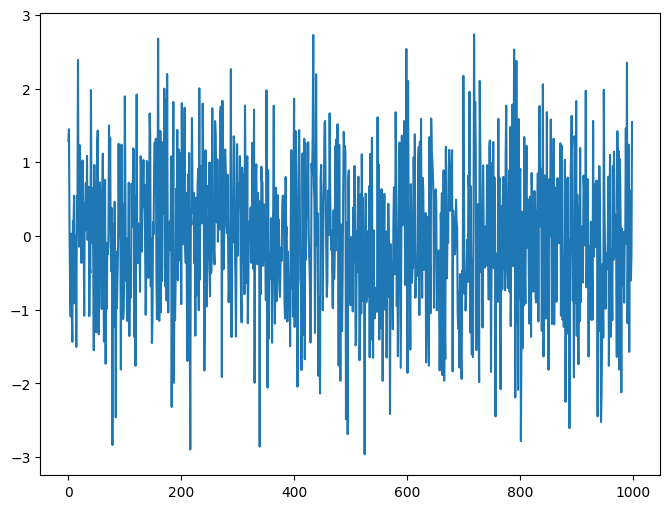

In [353]:
# vonal ábra
series.plot()
pyplot.show()

**Mit látunk?**

- Itt jól látható, hogy az értékek össze-vissza ingadoznak, semmilyen szabályosság nincs.

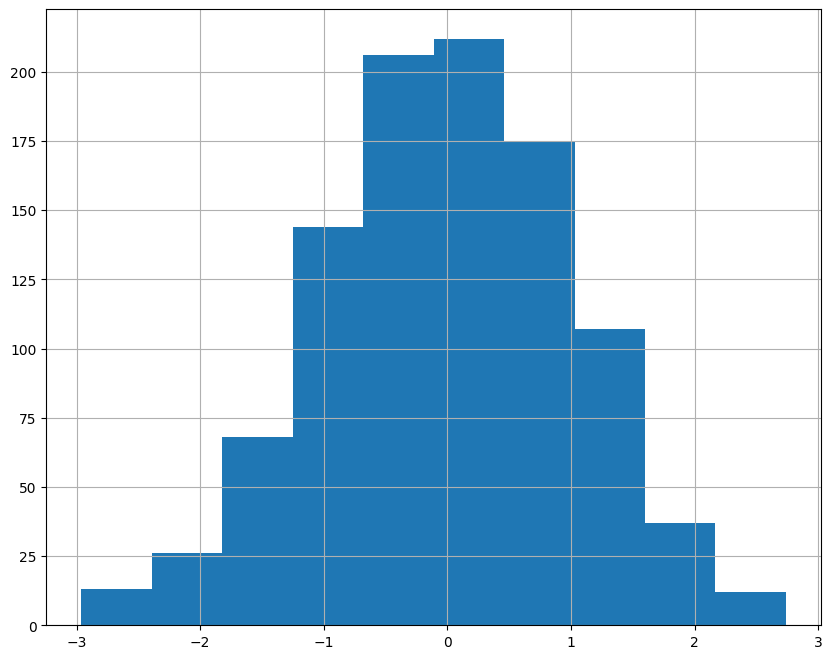

In [48]:
# histogram plot
series.hist()
pyplot.show()


**Mit látunk?**
- A hisztogram haranggörbe alakú, azaz normál eloszlásra utal → újabb megerősítés, hogy fehér zajról van szó.

Ez az egyik legfontosabb lépés:
- Ha az összes LAG* a konfidenciaintervallumon belül van, akkor:
  - nincs szignifikáns korreláció korábbi értékekkel
  - A sorozat nem előrejelezhető

LAG -  A "lag" (magyarul: eltolás vagy késleltetés) azt jelenti, hogy egy időbeli lépést visszalépünk az adatsorban, és megnézzük, hogy az aktuális érték mennyire függ a korábbi értékektől.

### 13. Autokorreláció és lag

Az **autokorreláció (autocorrelation)** azt mutatja meg, hogy egy idősor **mennyire hasonlít saját korábbi értékeire**. Más szóval: mennyire „emlékszik” az idősor a múltjára.

Ha az idősor értékei között **szisztematikus kapcsolat** van (például ha ma magas az érték, akkor holnap is az lesz),akkor **magas az autokorreláció**.  
Ha viszont minden érték teljesen véletlenszerű, **nincs korreláció** – ez a **fehér zaj** esete.



**Mit jelent a *lag*?**

A *lag* (késleltetés) azt jelenti, hogy az aktuális értéket összevetjük a **korábbi** értékekkel:

- **Lag 1 autokorreláció** → az aktuális értéket hasonlítja a **1 időlépéssel korábbihoz**  
- **Lag 2** → két lépéssel korábbi értékhez viszonyít  
- **Lag 12** → például egy évvel korábbi értékhez havi adatok esetén  

Így tudjuk megvizsgálni, hogy az idősorban **milyen ismétlődő minták vagy ciklusok** vannak.



#### 13.1. Életszerű példa – a napi hőmérséklet

Képzeljük el, hogy a napi hőmérsékletet 24 órás bontásban vizsgáljuk:

- A **mai déli hőmérséklet** általában **erősen korrelál** a **tegnapi déli hőmérséklettel**,  mert a napszakok és az időjárási viszonyok hasonlók.  
- Ugyanez a pont **negatívan korrelál** az **éjféli hőmérséklettel**, mert éjjel jellemzően lehűl a levegő, tehát amikor délben melegebb van,  
  akkor éjfélkor jellemzően hidegebb volt.  
- A **dél előtti vagy dél utáni órákkal** pedig csak **gyenge korreláció** figyelhető meg,mivel a hőmérséklet ilyenkor gyorsan változik, és nincs stabil kapcsolat.

Ez a példa jól mutatja, hogy az **autokorreláció az ismétlődő folyamatokat és ritmusokat** is képes felfedni az adatokban.


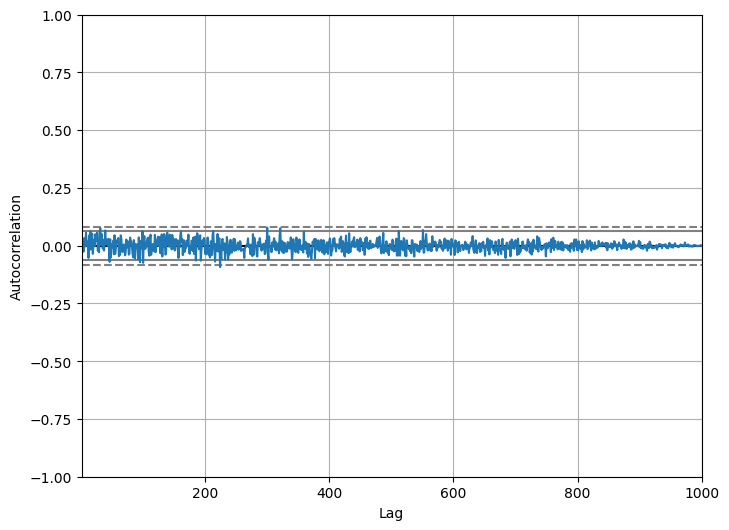

In [362]:
# autocorrelation
autocorrelation_plot(series)
pyplot.show()

**A fehér zaj autokorrelációja – mit látunk?**

Az ábrán a **fehér zaj (white noise)** idősor autokorrelációs függvénye (ACF) látható. A függvény azt mutatja meg, hogy az idősor értékei **mennyire függenek saját múltbeli értékeiktől**.


**Értelmezés**

- A **kék vonalak** az egyes *lag* értékekhez tartozó korrelációs együtthatókat mutatják.  
- A **szaggatott szürke sáv** a **konfidencia-intervallum** – azon belül az autokorreláció statisztikailag **nem szignifikáns**.  
- Látható, hogy **minden érték a 0 körül ingadozik**, és **nem lép ki a szürke sávból**.

Ez azt jelenti, hogy az idősor **nem mutat semmilyen kapcsolatot** a múltbeli értékeihez képest.



**Mit jelent ez?**

- A fehér zaj teljesen **véletlenszerű**: az egyik érték **nem befolyásolja** a következőt.  
- Ezért az autokorreláció **minden lag értéknél közel nulla**.  
- Nincs ismétlődés, nincs trend, nincs szezonalitás —  vagyis **nincs semmilyen előrejelezhető szerkezet** az adatokban.






#### 13.2. Példa: hőmérséklet-idősor autokorrelációja

A hőmérséklet tipikusan **nem fehér zaj**, hanem **erősen autokorrelált idősor**. Az egyik legjobb példa arra, amikor az aktuális értékek **szorosan összefüggnek a korábbiakkal**.

**Miért?**

- A **napszakok** miatt a hőmérséklet naponta **periodikusan ismétlődik** (reggel hűvös, délben meleg, este hűvös).
- A **tegnapi és mai hőmérséklet** között **magas pozitív korreláció** van, hiszen az időjárás nem változik drasztikusan egyik napról a másikra.
- Ugyanakkor az **éjféli és déli hőmérséklet** között gyakran **negatív korreláció** figyelhető meg, mert ha éjjel hideg van, nappal általában melegebb lesz.

Ezért az ilyen típusú adatok **előrejelezhetők** — a múltbeli minták segítenek becsülni a jövőt.



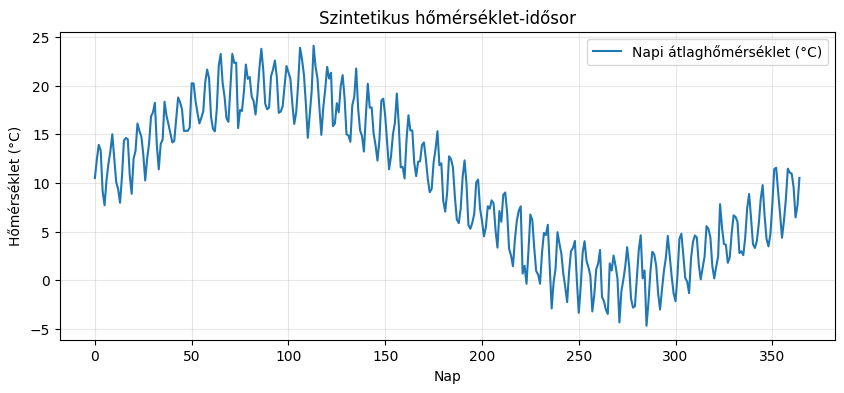

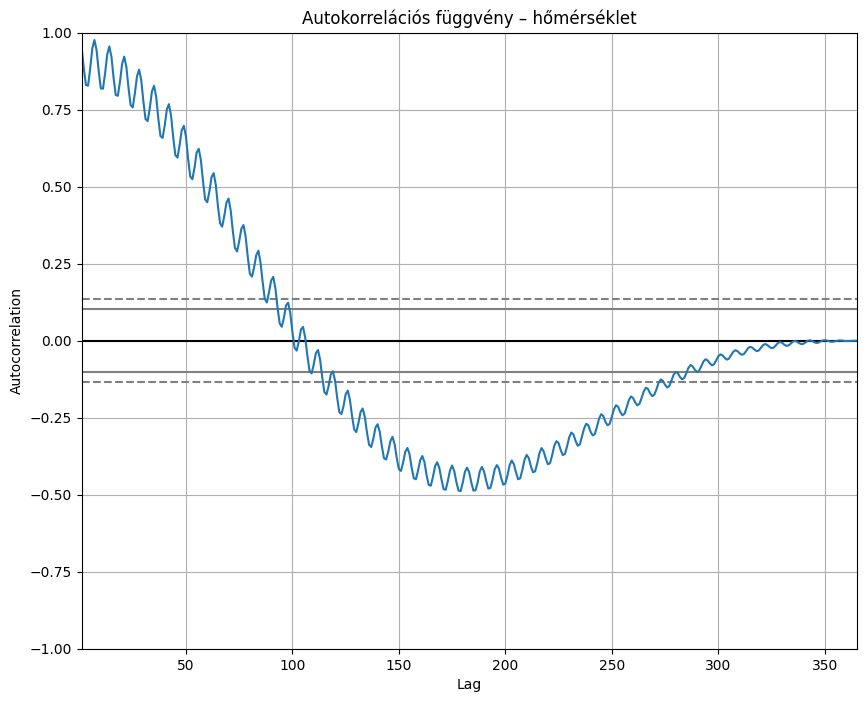

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import autocorrelation_plot

# Szintetikus napi hőmérséklet adatok generálása
np.random.seed(42)
days = 365  # 1 év
time = np.arange(days)

# Alap trend (pl. nyári melegebb, téli hidegebb)
trend = 10 + 10 * np.sin(2 * np.pi * time / 365)

# Napi ciklus + véletlen zaj
temperature = trend + 3 * np.sin(2 * np.pi * time / 7) + np.random.normal(0, 1, days)

# DataFrame
df_temp = pd.DataFrame({'Day': time, 'Temperature': temperature})
df_temp.set_index('Day', inplace=True)

# Hőmérséklet-idősor kirajzolása
plt.figure(figsize=(10,4))
plt.plot(df_temp['Temperature'], label='Napi átlaghőmérséklet (°C)')
plt.title("Szintetikus hőmérséklet-idősor")
plt.xlabel("Nap")
plt.ylabel("Hőmérséklet (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Autokorrelációs függvény (ACF)
autocorrelation_plot(df_temp['Temperature'])
plt.title("Autokorrelációs függvény – hőmérséklet")
plt.show()


**Mit olvashatunk ki az autokorrelációs ábrából?**

Ez az ábra a **szintetikus hőmérséklet-idősor autokorrelációját (ACF)** mutatja. A vízszintes tengely (lag) jelzi, hány nappal korábbi értékkel hasonlítjuk össze az aktuálisat,  
a függőleges tengely pedig az autokorreláció erősségét (–1 és +1 között).


**Mit látunk?**

1. **Erős pozitív korreláció kis lag-eknél (bal oldalon):**  
   - A görbe az 1–30 napos tartományban **magasan pozitív (0.8–1.0)**.  
   - Ez azt jelenti, hogy a hőmérséklet **nagyon hasonló a közelmúltbeli értékekhez** – tehát ha ma meleg van, valószínűleg holnap is meleg lesz.  
   - Ez a **rövid távú előrejelezhetőség** alapja.

2. **Hullámzó minta (periodicitás):**  
   - A korreláció **fokozatosan csökken**, majd **negatívvá válik**, és később újra **pozitív értéket vesz fel**.  
   - Ez a **szezonális ismétlődés** jele:a hőmérséklet **évente visszatérő ciklusokat** követ (tél–nyár–tél...).

3. **Negatív korreláció a középső szakaszon (~lag = 180 nap):**  
   - A görbe kb. fél évnél (lag ≈ 180 nap) **–0.5 körül van**, ami azt jelenti, hogy **a nyári és téli hőmérsékletek ellentétesek**.  
   - Ha nyáron magas a hőmérséklet, fél évvel később (télen) alacsony lesz.

**Összefoglalás**

| Tartomány | Autokorreláció | Jelentés |
|------------|----------------|-----------|
| 0–30 nap | +0.8…+1.0 | Rövid távú stabilitás, erős kapcsolat a közelmúlt értékeivel |
| ~180 nap | –0.5 | Ellentétes évszak (nyár vs tél) |






### 14. Random Walk (Véletlen bolyongás)

**Honnan tudod, hogy az idősoros problémád előrejelezhető?**

Ez az egyik legfontosabb kérdés az idősor-előrejelzésben. Sokszor azt hisszük, hogy ha egy adatsor „irányt mutat”, akkor **előrejelezhető**, pedig lehet, hogy valójában csak **véletlen bolyongás** (random walk) áll a háttérben.


**Mi az a véletlen bolyongás?**

A **Random Walk** (véletlen bolyongás) egy olyan idősor, ahol az aktuális érték az előző értékből indul ki, és egy **véletlen zaj** hozzáadásával módosul:

$$
x_t = x_{t-1} + \varepsilon_t
$$

ahol  
- \(x_t\): az aktuális érték  
- \(x_{t-1}\): az előző időpont értéke  
- \(\varepsilon_t\): véletlen zaj (fehér zaj, pl. normális eloszlásból)


**Mit jelent ez intuitíven?**

- A random walk **nem teljesen véletlen** – van **memóriája**, mert az új érték az előzőre épül.  
- Ugyanakkor **nem előrejelezhető**, mert a zaj  minden lépésben új, véletlen irányt ad.  
- Ezért a sor **lassan elsodródhat** felfelé vagy lefelé, de **nem tér vissza az átlaghoz**.

<div style="background-color:#e8fbe8; border-left:6px solid #16a34a; padding:12px; border-radius:8px;">
<b><strong>Példa:</strong></b><br>

<div style="text-align:center;">
  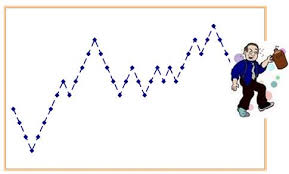
  <p style="font-style:italic; color:gray; margin-top:6px;">
    4. ábra. – Egy részeg ember elindul a városban
  </p>
</div>


egy részeg ember elindul a városban, és minden lépésnél véletlenszerűen dönt, hogy jobbra vagy balra megy —  összességében lesz valamilyen iránya, de **nem tudjuk megmondani, hol lesz a következő pillanatban**.
</div>

**Fontos különbség a Fehér zajhoz képest**

| Tulajdonság | **Fehér zaj** | **Random walk** |
|--------------|---------------|-----------------|
| Átlag | Állandó | Változik (elsodródik) |
| Szórás | Állandó | Növekszik az idővel |
| Autokorreláció | Nincs | Erős, mert \(x_t\) függ \(x_{t-1}\)-től |
| Előrejelezhetőség | Nem jósolható | Látszólag trendet mutat, de mégsem jósolható |



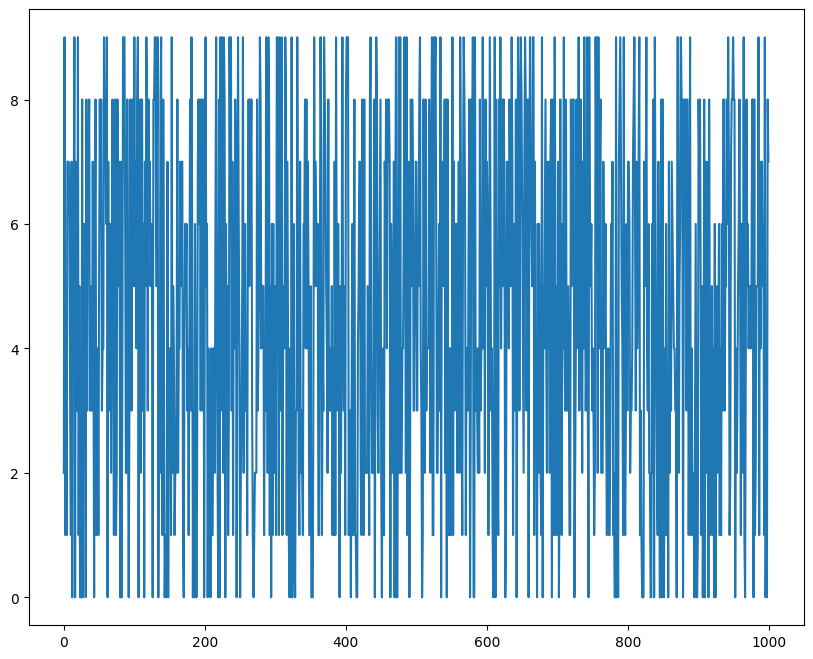

In [59]:
# egy véletlenszerű számsorozat készitése és ábrázolása
from random import seed
from random import randrange
from matplotlib import pyplot
seed(1)
series = [randrange(10) for i in range(1000)]
pyplot.plot(series)
pyplot.show()


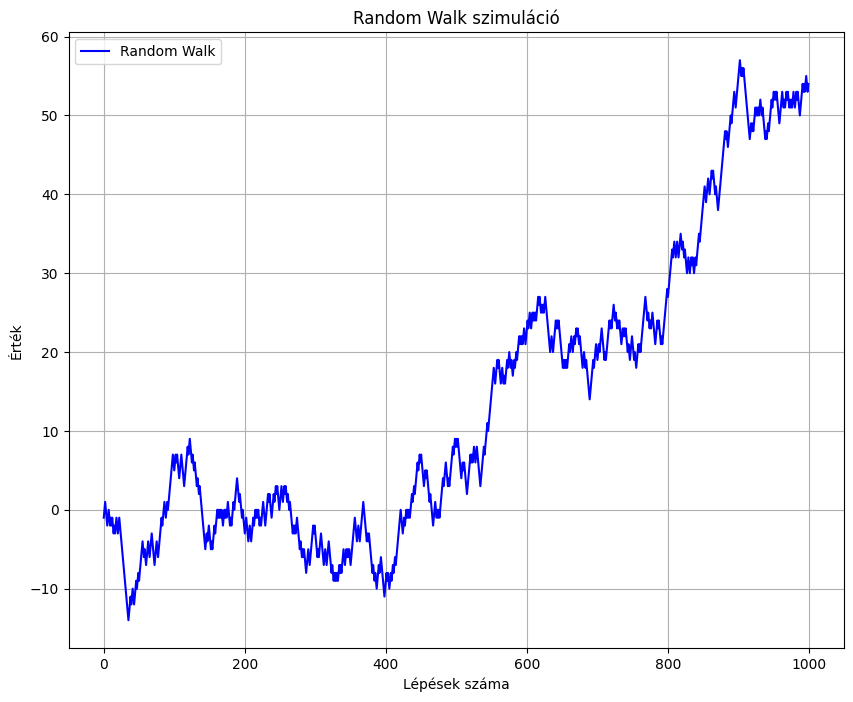

In [60]:
# random walk készítése és ábrázolása
from random import seed
from random import random
from matplotlib import pyplot

# Véletlenszerűség inicializálása, hogy a futások ugyanazt az eredményt adják
seed(1)

# Üres lista a random walk értékeinek tárolására
random_walk = list()

# Random walk kezdő értékének beállítása: -1 vagy 1, 50-50% valószínűséggel
random_walk.append(-1 if random() < 0.5 else 1)

# A random walk generálása 1000 lépésen keresztül
for i in range(1, 1000):
    # Mozgás irányának meghatározása: -1 (le) vagy +1 (fel), 50-50% valószínűséggel
    movement = -1 if random() < 0.5 else 1

    # Az új érték kiszámítása az előző érték alapján
    value = random_walk[i-1] + movement

    # Az új érték hozzáadása a random walk listához
    random_walk.append(value)

# Random walk ábrázolása vonaldiagramként
pyplot.plot(random_walk, color='blue', label='Random Walk')
pyplot.title('Random Walk szimuláció')
pyplot.xlabel('Lépések száma')
pyplot.ylabel('Érték')
pyplot.grid(True)
pyplot.legend()
pyplot.show()

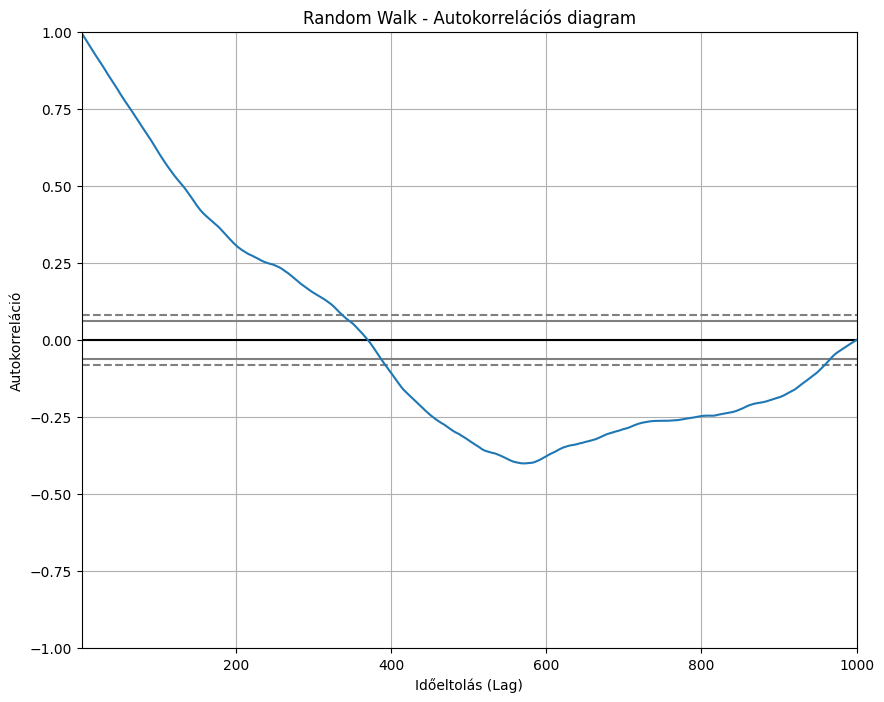

In [61]:
# Autokorrelációs diagram készítése
# Megmutatja, hogy mennyire korrelálnak az értékek különböző időeltolásoknál
autocorrelation_plot(random_walk)
pyplot.title('Random Walk - Autokorrelációs diagram')
pyplot.xlabel('Időeltolás (Lag)')
pyplot.ylabel('Autokorreláció')
pyplot.grid(True)
pyplot.show()

**Mit látunk?**

- Ez a diagram egy Random Walk (véletlen bolyongás) autokorrelációs függvényét mutatja.
- Az X tengely az időeltolást (lag), az Y tengely pedig az autokorreláció értékét jelzi.
- Az autokorreláció 1-ről indul, majd lassan csökken nulláig, ami azt jelenti, hogy a múltbeli értékek hosszú ideig befolyásolják a jövőbelieket.

A görbe alakja azt mutatja, hogy a Random Walk nem stacionárius:
- az értékek között tartós függés áll fenn, tehát a folyamat nem tér vissza az átlaghoz.

**Összefoglalás:**
A Random Walk autokorrelációja lassan tűnik el → hosszú távú memória, nem stacionárius viselkedés.

### 15. Mi az, hogy egy idősor stacionárius?

Egy idősor **stacionárius**, ha **statisztikai tulajdonságai nem változnak az idő múlásával**.  
Ez azt jelenti, hogy:

- Az **átlag** (mean) időben állandó,  
- A **szórás** (variance) állandó,  
- Az **autokorrelációs szerkezet** (mintázat) nem függ attól, mikor vizsgáljuk az idősor egy részét.


**Stacionárius idősor például:**
- Fehér zaj  
- Véletlen ingadozások, de nincs trend vagy szezonális hatás

**Nem stacionárius idősor például:**
- Trenddel rendelkező sor (pl. folyamatos növekedés)  
- Szezonális mintázatot mutató adatok (pl. hőmérséklet, utasszám)


**Miért fontos ez?**

A legtöbb idősor-elemző és előrejelző modell (pl. **ARIMA**, **SARIMA**) **stacionárius adatokkal működik helyesen**.

Ha az idősor **nem stacionárius**, akkor:
- az átlag és a szórás folyamatosan változik,  
- a múltbeli értékek **nem adnak megbízható képet a jövőről**,  
- a modell téves mintázatokat tanulhat.

Ezért gyakori lépés az **idősor transzformálása** (pl. differenciálás, logaritmus, detrend) a stacionaritás elérése érdekében.



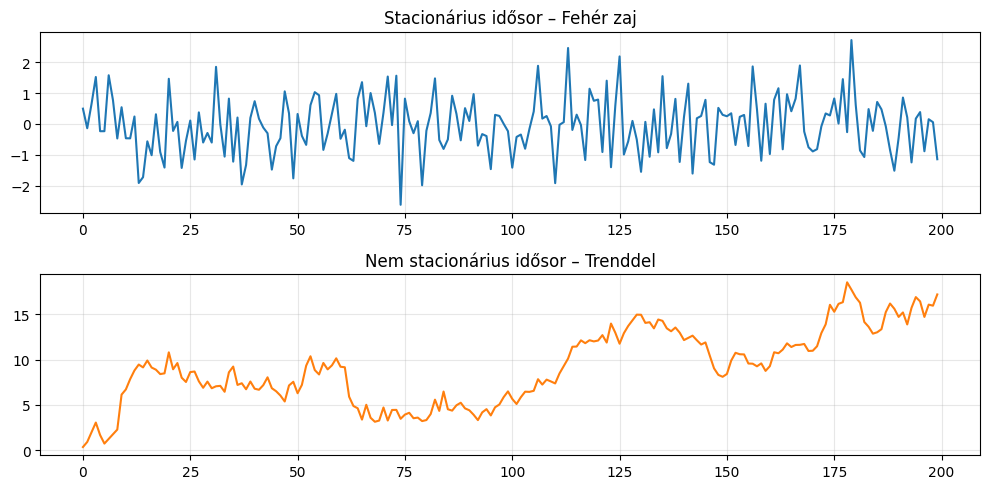

--- Fehér zaj ---
ADF statisztika: -14.744
p-érték: 0.0000
 Valószínűleg stacionárius (elutasítjuk a nullhipotézist)

--- Trenddel rendelkező sor ---
ADF statisztika: -1.820
p-érték: 0.3707
 Valószínűleg nem stacionárius (nem utasítjuk el a nullhipotézist)



In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Adatok előkészítése
np.random.seed(42)
n = 200

# Stacionárius idősor (fehér zaj)
white_noise = np.random.normal(0, 1, n)

# Nem stacionárius idősor (növekvő trend)
trend = np.cumsum(np.random.normal(0, 1, n))  # kumulatív összeg → trend keletkezik

# Ábrázolás
plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
plt.plot(white_noise, color='tab:blue')
plt.title("Stacionárius idősor – Fehér zaj")
plt.grid(True, alpha=0.3)

plt.subplot(2,1,2)
plt.plot(trend, color='tab:orange')
plt.title("Nem stacionárius idősor – Trenddel")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Augmented Dickey-Fuller teszt (ADF) – stacionaritás ellenőrzése
def adf_test(series, name):
    result = adfuller(series)
    print(f"--- {name} ---")
    print(f"ADF statisztika: {result[0]:.3f}")
    print(f"p-érték: {result[1]:.4f}")
    if result[1] < 0.05:
        print(" Valószínűleg stacionárius (elutasítjuk a nullhipotézist)\n")
    else:
        print(" Valószínűleg nem stacionárius (nem utasítjuk el a nullhipotézist)\n")

adf_test(white_noise, "Fehér zaj")
adf_test(trend, "Trenddel rendelkező sor")


### 16. Random walk és a stacionárius jel kapcsolata

A **véletlen séta (Random Walk)** az idősorelemzés egyik legfontosabb – és legfélreértettebb – alapfogalma.  
Bár elsőre úgy tűnhet, hogy a random walk csak véletlenszerű ingadozásokból áll, valójában **nem stacionárius folyamat**, mert az értékei **idővel elvándorolnak** egy irányba.


**Miért nem stacionárius?**

- A random walk minden új megfigyelése az előző érték **és egy véletlen lépés** összege:  
  $$
  x_t = x_{t-1} + \varepsilon_t
  $$
  ahol $$(\varepsilon_t)$$ a véletlen komponens (fehér zaj).

- Mivel minden új érték az előzőből épül, a **hiba halmozódik** → az idősor átlagosan elvándorol. Ezért a **trend (drift)** idővel növekszik, és az **átlag, szórás nem állandó** → nem stacionárius.

**Mit tehetünk?**

A random walk **stacionáriussá tehető**, ha az **első különbséget** (first difference) képezzük:

$$
\Delta x_t = x_t - x_{t-1}
$$

Ekkor minden elem azt mutatja, **mekkora változás** történt az előző időponthoz képest.  
Ezzel a lépéssel eltávolítjuk a trendet, és **a különbségek eloszlása közel stacionárius lesz**.



**Differenciálás gyakorlati értelme**

- Eltávolítja a **trend komponenseket**,  
- Kiegyensúlyozza a **szórást az időben**,  
- Előkészíti az idősorokat **ARIMA-típusú modellekhez**.

Az eredmény: egy **stabil, stacionárius folyamat**, amellyel érdemes tovább dolgozni.



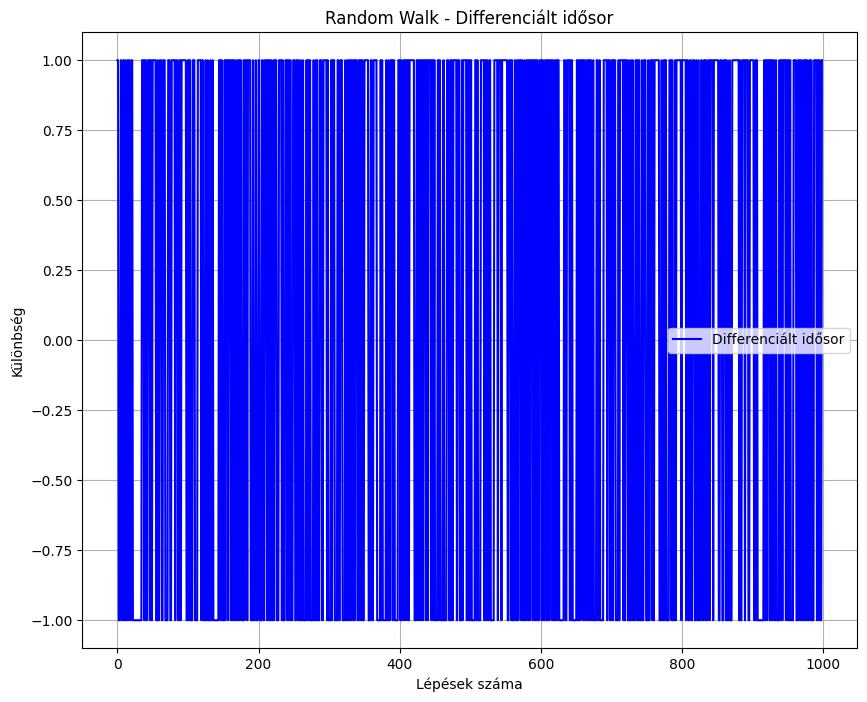

In [65]:
# Differenciálás
# A random walk elsőrendű különbségeinek kiszámítása
diff = list()

# Minden elemre kiszámoljuk a különbséget az előző értékhez képest
# Ezáltal eltávolítjuk a trendet, és közelebb kerülünk a stacionaritáshoz
for i in range(1, len(random_walk)):
    value = random_walk[i] - random_walk[i - 1]
    diff.append(value)

# Vonalábra készítése a differenciált idősorról
# Ez megmutatja, hogy az idősor stacionáriussá vált-e a differenciálás után
pyplot.plot(diff, color='blue', label='Differenciált idősor')
pyplot.title('Random Walk - Differenciált idősor')
pyplot.xlabel('Lépések száma')
pyplot.ylabel('Különbség')
pyplot.grid(True)
pyplot.legend()
pyplot.show()


A kapott jelünk valójában egy WHITE NOISE lett.

### 17. Mi a legegyszerűbb előrejelzési (forecasting) módszer?

Miután megismertük, hogy mikor **nem** érdemes előrejelzést készíteni (pl. fehér zaj vagy random walk esetén), felmerül a kérdés: **hogyan kezdjük az előrejelzést egy "értelmes" idősoron**?

Ha a jel **nem véletlenszerű**, hanem tartalmaz:
- **trendeket** (hosszú távú növekedés vagy csökkenés),  
- **szezonális mintázatokat** (pl. ismétlődő évek, hónapok, napszakok),  
- **autokorrelációt** (az értékek kapcsolatban vannak a korábbi értékekkel),

akkor már **jó eséllyel előrejelezhető**.



In [68]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

# Airline dataset betöltése
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv")
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)


### 18. Naiv előrejelzés (Repeat Last – ismétlés alapú módszer)

A **naiv előrejelzés** a legegyszerűbb, ugyanakkor meglepően hasznos kiindulópont.

**Elv:**

A következő időpont értéke = az utolsó ismert érték.

Formálisan:
$$
\hat{y}_{t+1} = y_t
$$

**Jellemzői:**
- **Egyszerű**: nem igényel modellt, tanítást vagy paramétert.  
- **Gyors**: azonnal kiszámítható bármely idősorra.  
- **Korlátozott**: csak akkor működik elfogadhatóan, ha **nincs erős trend vagy szezonális hatás**.  
  Ha az adatok nőnek, csökkennek vagy ismétlődnek, a naiv modell hamar lemarad az aktuális értékektől.

Ezért a **naiv módszer** jó *baseline modell* — referenciaként szolgál a bonyolultabb előrejelzésekhez (pl. ARIMA, Holt-Winters, Prophet).


In [70]:
df['Naive'] = df['Passengers'].shift(1)

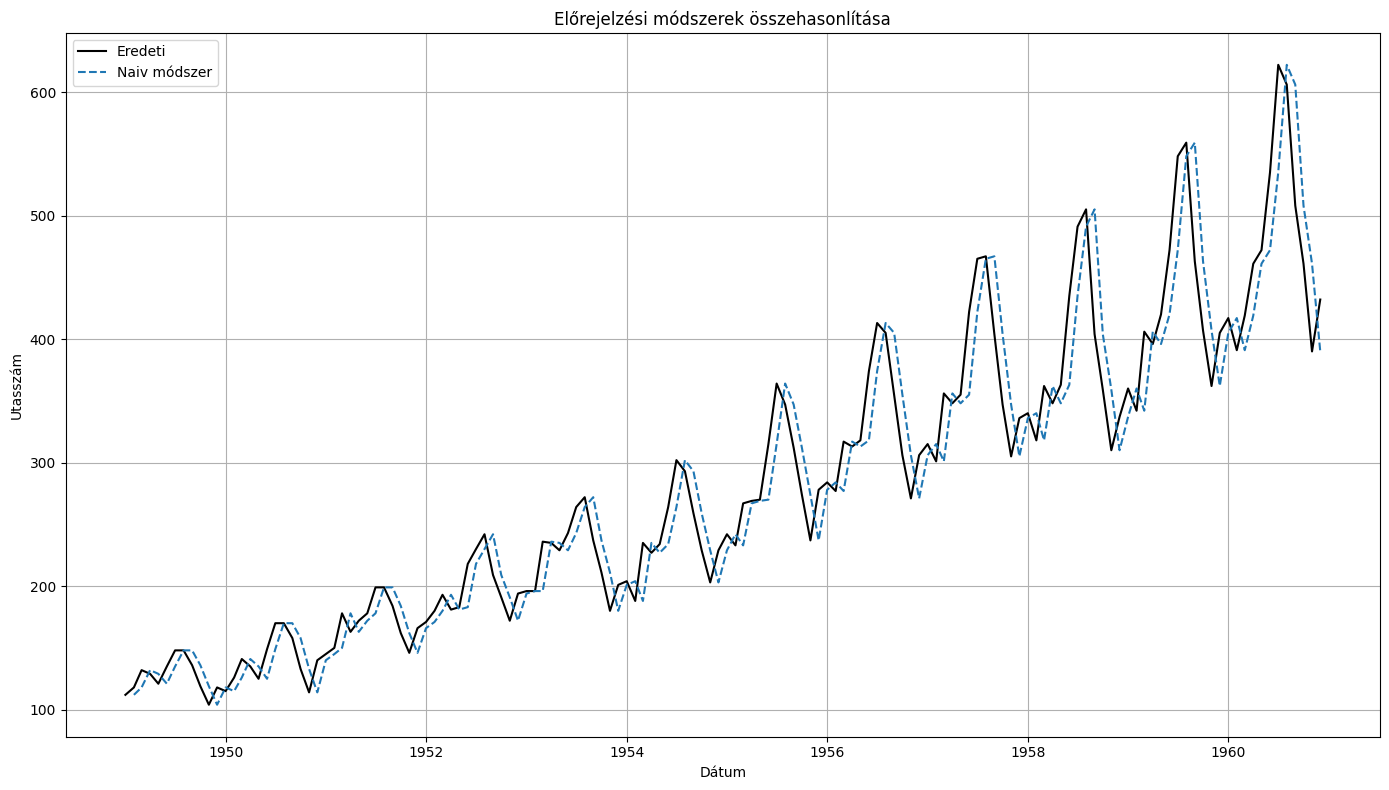

In [71]:
plt.figure(figsize=(14, 8))
plt.plot(df['Passengers'], label='Eredeti', color='black')
plt.plot(df['Naive'], label='Naiv módszer', linestyle='--')
plt.title("Előrejelzési módszerek összehasonlítása")
plt.xlabel("Dátum")
plt.ylabel("Utasszám")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 19. Mozgóátlag (Moving Average – MA)

A mozgóátlag az egyik **leggyakrabban használt alapmódszer** az idősorelemzésben. Egyszerre szolgál **simításra** és **egyszerű előrejelzésre**.

**Elv:**

Az előrejelzés az előző *k* értékek átlagán alapul:
$$
\hat{y}_{t+1} = \frac{y_t + y_{t-1} + \ldots + y_{t-k+1}}{k}
$$

ahol *k* a **window size** (ablakméret), vagyis hány előző értéket veszünk figyelembe.

**Tulajdonságai**

- **Zajt simít** – a rövid távú ingadozásokat kiszűri, így jobban látszik a **trend**.  
- **Könnyen értelmezhető** – nem igényel bonyolult statisztikát vagy paraméterezést.  
- **Gyenge pontja**: ha erős **szezonális hatás** vagy **gyors trendváltás** van, a mozgóátlag **lemarad** a valós értékektől.  
- Minél **nagyobb az ablakméret (k)**, annál simább lesz a görbe, de annál lassabban reagál a változásokra.


**Mikor használjuk?**

- Ha a cél **trendek vagy hosszabb távú mozgások** feltárása.  
- Ha a cél **rövid távú előrejelzés**, akkor inkább exponenciális simítást (Holt–Winters) érdemes használni.



In [73]:
df['MA_3'] = df['Passengers'].rolling(window=3).mean()


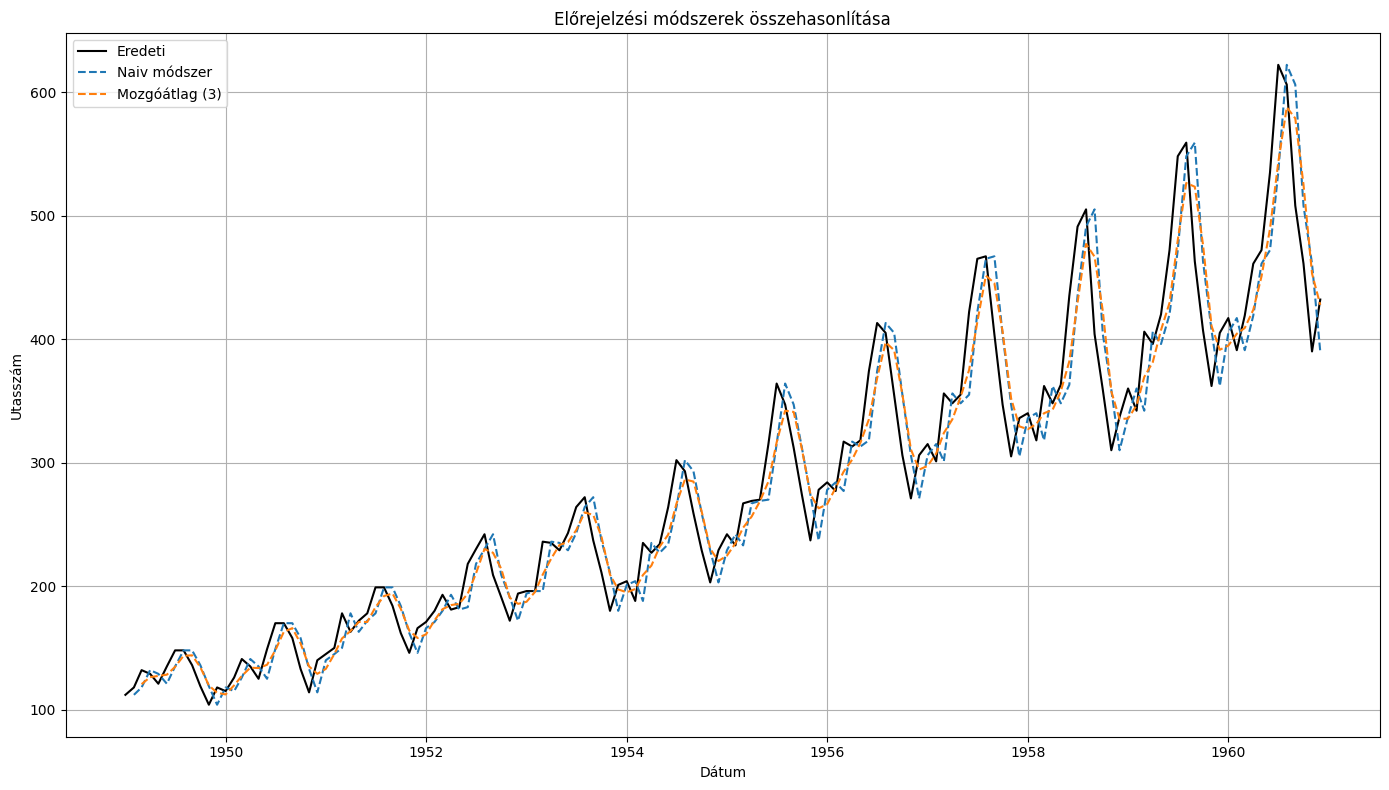

In [74]:
plt.figure(figsize=(14, 8))
plt.plot(df['Passengers'], label='Eredeti', color='black')
plt.plot(df['Naive'], label='Naiv módszer', linestyle='--')
plt.plot(df['MA_3'], label='Mozgóátlag (3)', linestyle='--')
plt.title("Előrejelzési módszerek összehasonlítása")
plt.xlabel("Dátum")
plt.ylabel("Utasszám")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 20. Egyszerű Exponenciális Simítás (SES)

A **Simple Exponential Smoothing (SES)** a mozgóátlag továbbfejlesztett változata. Míg a mozgóátlag minden múltbeli értéket egyformán súlyoz,  
az **exponenciális simítás** a **frissebb értékeknek nagyobb jelentőséget** ad.


**Elv:**
- Az új előrejelzett érték az előző megfigyelések **súlyozott átlaga**,  
- ahol az **időben régebbi adatok súlya exponenciálisan csökken**.

Formálisan:
$$
\hat{y}_{t+1} = \alpha \cdot y_t + (1 - \alpha) \cdot \hat{y}_t
$$

ahol:
- α  a **simátási páraméter** (0 < α < 1),
- ha α nagy → gyorsan reagál az új értékekre,  
- ha α kicsi → lassabban, simábban követi a trendet.



**Mikor használjuk?**

- Ha az idősorban **nincs erős trend vagy szezonalitás**, de **enyhe, fokozatos változás** megfigyelhető.
- Ha egy **egyszerű, stabil, zajszűrő előrejelzésre** van szükség.
- Kiváló első lépés az **ARIMA-modellek** előkészítése előtt.




In [76]:
ses_model = SimpleExpSmoothing(df['Passengers']).fit()
df['SES'] = ses_model.fittedvalues

C:\Users\koros\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


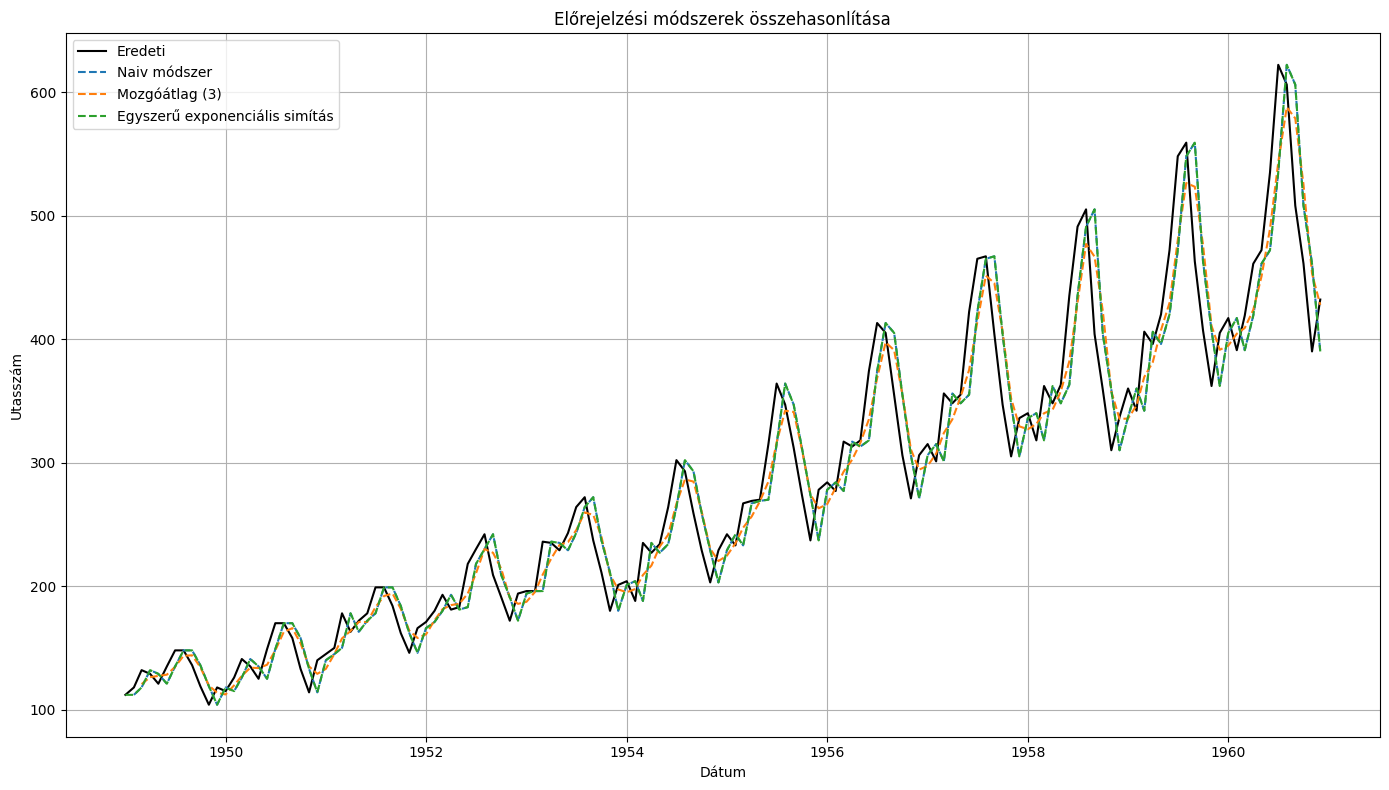

In [77]:
plt.figure(figsize=(14, 8))
plt.plot(df['Passengers'], label='Eredeti', color='black')
plt.plot(df['Naive'], label='Naiv módszer', linestyle='--')
plt.plot(df['MA_3'], label='Mozgóátlag (3)', linestyle='--')
plt.plot(df['SES'], label='Egyszerű exponenciális simítás', linestyle='--')
plt.title("Előrejelzési módszerek összehasonlítása")
plt.xlabel("Dátum")
plt.ylabel("Utasszám")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 21. ARIMA modell

Az **ARIMA** a klasszikus idősor-előrejelző modellek „nagyágyúja”. A rövidítés jelentése: **AutoRegressive Integrated Moving Average**.  
Ez a modell **három komponens kombinációja**, amelyek együtt képesek trendet, zajt és autokorrelációt kezelni.


**Az ARIMA komponensei**

| Betűjel | Jelentés | Funkció | Magyarázat |
|:--------|:----------|:--------|:------------|
| **AR(p)** | AutoRegresszív rész | múltbeli értékek felhasználása | az előző megfigyelésekből tanul (pl. az elmúlt hónap utasszáma alapján becsül) |
| **I(d)** | Integrált (differenciált) rész | a nem stacionárius jel stacionáriussá tétele | az idősor trendjét eltávolítjuk differenciálással |
| **MA(q)** | Mozgóátlag rész | a múltbeli előrejelzési hibák felhasználása | a modell a korábbi hibák mintázatát is figyelembe veszi |



**Intuíció**

- Az **ARIMA(p, d, q)** modellben:
  - **p** → hány múltbeli értéket vegyen figyelembe (autoregresszió),
  - **d** → hány differenciálás szükséges a stacionaritáshoz,
  - **q** → hány múltbeli hiba értéket vegyen figyelembe (mozgóátlag rész).

Ez a kombináció lehetővé teszi, hogy a modell **megtanulja a múltbeli trendeket és korrekciós mintákat**, így a legtöbb valós idősorra jól illeszthető.



**Mikor használjuk az ARIMA-t?**

- Ha az idősor **nem teljesen véletlenszerű (nem fehér zaj)**,  
- Ha **van trend**, de **nincs erős szezonális ismétlődés** (arra a SARIMA alkalmasabb),  
- Ha az idősor **stacionáriussá tehető differenciálással**,  
- Ha **kevés adatsor** áll rendelkezésre, és mélytanulás még nem indokolt.



**Modellépítés lépései röviden**

1. **Vizualizáció** – az idősor trendjeinek, szezonalitásának megértése.  
2. **Stacionaritás vizsgálata** – szükség esetén differenciálás.  
3. **Paraméterkeresés** – p, d, q kiválasztása (pl. AIC alapján).  
4. **Modellillesztés és előrejelzés** – `ARIMA(p, d, q)` objektummal.  
5. **Értékelés** – RMSE, MAPE, vizuális illeszkedés vizsgálata.



### 21.1. Autokorrelációs Függvény (ACF)

Az **autokorreláció** azt mutatja meg, hogy az idősor **aktuális értékei mennyire hasonlítanak a korábbi (eltolt) értékekhez**.  
Más szóval: mennyire „emlékszik” az idősor a múltjára.

**Mit mér az ACF?**

- ACF (Autocorrelation Function): az idősor **önmagával vett korrelációja különböző időeltolások mellett (lag)**.  
- Ha például az 1. lag autokorreláció magas, akkor az adott érték **erősen függ az előzőtől**.
- Ha több lag is szignifikáns, akkor **tartós kapcsolat** vagy **ismétlődő mintázat (szezonális hatás)** is jelen lehet.


**Miért fontos az ACF?**

- Az ACF **segít meghatározni az ARIMA modell q paraméterét**, vagyis a **mozgóátlag (MA)** komponens nagyságát.  
- Azt mutatja meg, **hány múltbeli hiba** befolyásolja még a jelen értéket.

**Mikor használjuk?**

- Amikor az idősor **stacionáriussá vált**, és az **MA(q)** paramétert szeretnénk becsülni.
- Ha **lassan csökken** az autokorreláció → trend vagy szezonalitás van jelen.  
- Ha **hirtelen eltűnik** néhány lag után → rövid memóriájú, véletlenszerű folyamat.



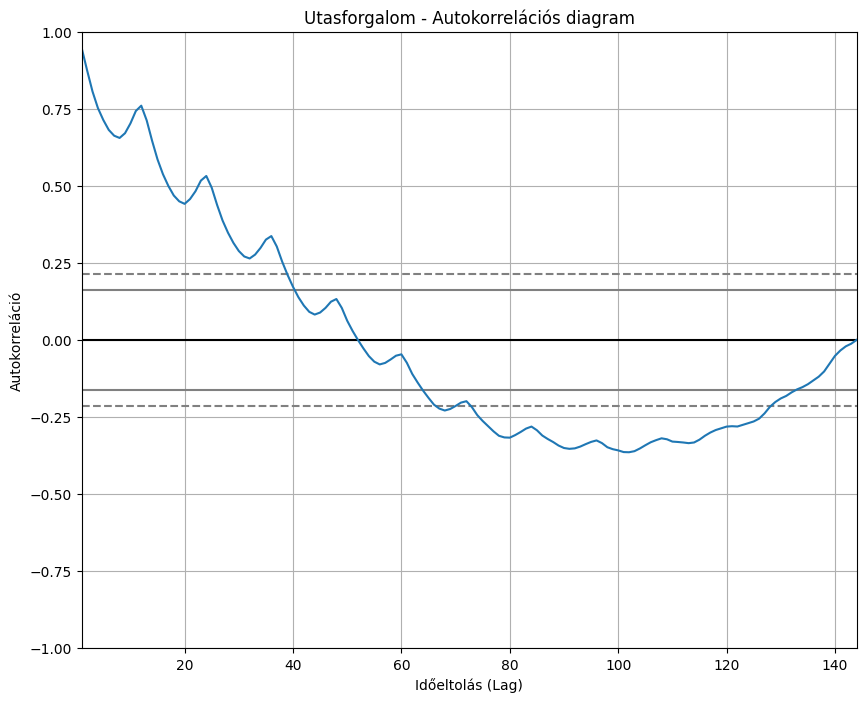

In [80]:
# Autokorrelációs diagram készítése
# Megmutatja, hogy mennyire korrelálnak az értékek különböző időeltolásoknál
autocorrelation_plot(df['Passengers'])
pyplot.title('Utasforgalom - Autokorrelációs diagram')
pyplot.xlabel('Időeltolás (Lag)')
pyplot.ylabel('Autokorreláció')
pyplot.grid(True)
pyplot.show()

**ACF ábra (q meghatározásához)**

**Amit látunk az ábrán:**

- Az **autokorreláció (ACF)** értéke **lassan csökken**, sok lag értéknél még mindig kilóg a konfidenciasávból.
- Ez **tipikus MA(q)** viselkedés – vagyis a múltbeli **hibaértékek** hatása tartós.
- Itt legalább **q = 2 vagy q = 3** indokoltnak tűnik, mert kb. 3 lag után kezd el meredeken csökkenni a hatás.


**Értelmezés lépésről lépésre**

1. **Ha az ACF fokozatosan csökken** → az idősor valószínűleg trendes vagy szezonalitásos.  
2. **Ha néhány lag után nullára zuhan** → rövid emlékezetű MA folyamat.  
3. **Ha szinuszos mintázatot mutat** → ismétlődő ciklusok (pl. éves, havi szezonalitás).  
4. **Ha lag 12 körül újra kilóg** → valószínű **szezonális komponens** (pl. 12 hónapos évhatás).

**Következtetés**

Ebben az ábrában:

- Az autokorreláció **fokozatosan csökken**,  
- majd **lag ≈ 12** körül ismét kiugrást mutat → **éves szezonalitásra utal**,
- így a modellbe érdemes lehet **szezonális kiterjesztést (SARIMA)** is beépíteni.

Válasszunk **q = 2 vagy 3**, és fontoljuk meg a **szezonális komponenst (lag = 12)** is.



### 21.2 Parciális Autokorreláció (PACF)

A **Parciális Autokorrelációs Függvény (PACF)** az egyik legfontosabb diagnosztikai eszköz az idősorelemzésben. Segítségével meghatározható, hogy az idősor **hány múltbeli értéket** (lag-et) használhatunk az autoregresszív modellben (AR).

**Mit mér a PACF?**

- Az idősor **aktuális értéke és a múltbeli értékek közötti kapcsolatot** mutatja, **de csak a közvetlen, „tiszta” kapcsolatot**, azaz kiszűri a köztes lag-ek hatását.  
  Például:
  - Az ACF azt mutatja, *mennyi a kapcsolat a mostani és a 3. korábbi érték között*,
  - A PACF pedig csak azt, *mennyi ebből a kapcsolatból származik közvetlenül, nem közvetve* (pl. az 1. és 2. lag-en keresztül).

**Összefoglalva**

| Módszer | Mit mér? | Mikor használjuk? |
|----------|-----------|-------------------|
| **ACF (Autokorreláció)** | Az értékek korrelációját minden korábbi lag-gel | MA (Moving Average) komponens becslésére |
| **PACF (Parciális autokorreláció)** | Az értékek korrelációját **csak a közvetlen lag-ekkel** | AR (Autoregresszív) komponens becslésére |


**Jelentősége**

- A PACF **segít meghatározni az AR(p)** modell **p paraméterét**.  
- Ha például a PACF az első 2 lag-nál szignifikáns (a konfidenciahatáron kívül esik), az azt jelenti, hogy az autoregresszív modell **p = 2** értékkel jól leírja az idősor viselkedését.


**Mikor használjuk?**

- Ha **autoregresszív (AR)** modellt szeretnénk illeszteni, vagy az ARIMA **p paraméterét** akarjuk meghatározni.  
- Ha már differenciáltuk az idősorunkat, és az stacionáriussá vált.



<Figure size 800x400 with 0 Axes>

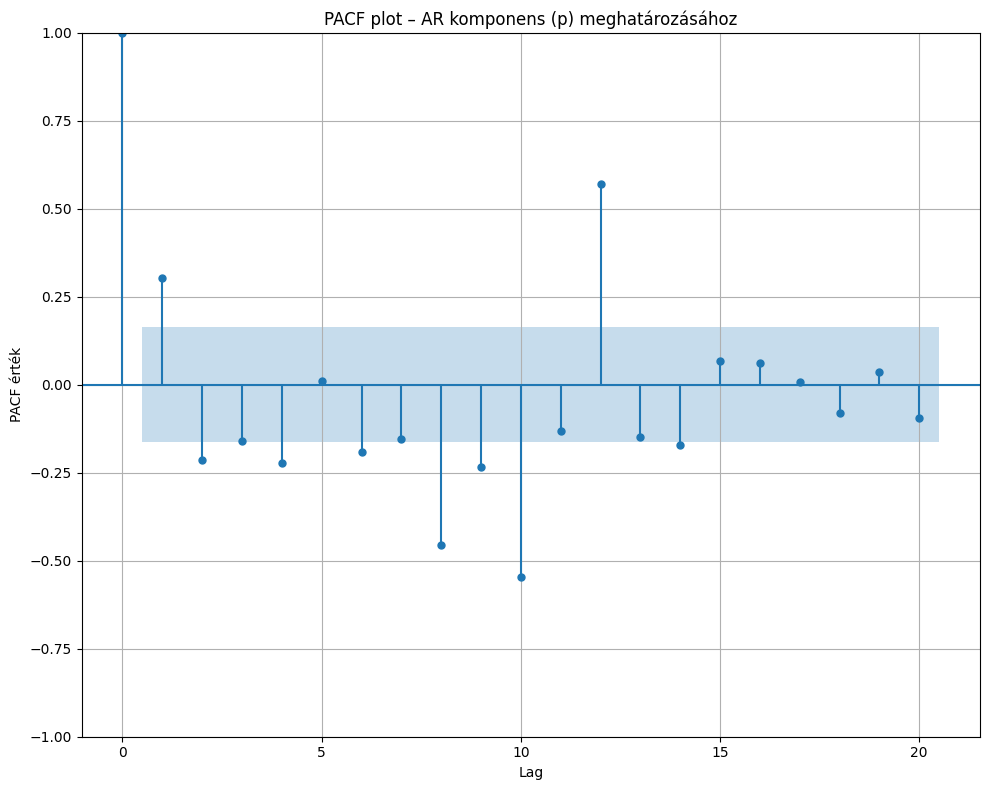

In [83]:
from statsmodels.graphics.tsaplots import plot_pacf
# 2. Differenciálás, ha nem stacionárius
series = df['Passengers'].diff().dropna()

# 3. PACF plot
plt.figure(figsize=(8, 4))
plot_pacf(series, lags=20, method='ywm')  # ywm = Yule-Walker, stabil
plt.title("PACF plot – AR komponens (p) meghatározásához")
plt.xlabel("Lag")
plt.ylabel("PACF érték")
plt.grid(True)
plt.tight_layout()
plt.show()


**PACF ábra (p meghatározásához)**

A **PACF (Parciális Autokorrelációs Függvény)** azt mutatja meg, hány múltbeli érték (lag) befolyásolja **közvetlenül** az idősor jelenlegi értékét.  
Ezzel határozható meg az **ARIMA modell AR(p)** komponense.



**Mit látunk az ábrán?**

- Az **első lag (Lag 1)** értéke **jelentős** és **kilóg** a kék konfidenciasávból → erős közvetlen kapcsolat az előző időszakkal.  
- A **második lag (Lag 2)** értéke még **kisebb, de szintén szignifikáns**, ami azt jelenti, hogy az idősor még a két időszakkal korábbi értékét is figyelembe veszi.  
- A **további lag-ek** (Lag 3-tól kezdve) már **a konfidenciasávon belül maradnak**, tehát azok hatása statisztikailag **nem szignifikáns**.



**Értelmezés**

Ez a viselkedés **klasszikus AR(2)** mintázatot mutat:

- Az első és második lag szignifikáns,  
- a harmadik és további lag-ek már nem → az autoregresszív kapcsolat **második rendű**.

| Lag | PACF érték | Értelmezés |
|------|-------------|------------|
| 1 | Kilóg a sávból | Erős kapcsolat az előző értékkel |
| 2 | Kisebb, de még szignifikáns | Mérsékelt hatás 2 lépéssel visszafelé |
| 3+ | A sávon belül | Már nincs szignifikáns kapcsolat |


**Következtetés**

- Az első két PACF érték jelentősen nem nulla, a többi már konfidenciahatáron belül marad.  
- **Javasolt AR komponens: p = 2**

Ez azt jelenti, hogy az idősor **két korábbi megfigyelésre** épít, tehát az előrejelzést az utolsó két érték együttesen befolyásolja.





### 21.3. Ajánlott modell: ARIMA(p=2, d=1, q=2)

A korábbi elemzések (ACF + PACF) alapján:
- **p = 2** → az autoregresszív (AR) rész két múltbeli értéket vesz figyelembe  
- **q = 2** → a mozgóátlag (MA) rész két múltbeli hibát vesz figyelembe  
- **d = 1** → az idősor egyszeri differenciálása után válik **stacionáriussá**


**De honnan jön a `d = 1` érték?**

Az ARIMA modellben:

$$
ARIMA(p, d, q)
$$

- `p`: az **autoregresszív komponens** rendje (PACF alapján),
- `d`: a **differenciálás foka**, amellyel az idősor **stacionáriussá** tehető,
- `q`: a **mozgóátlag komponens** rendje (ACF alapján).



**Miért kell differenciálni?**

Az eredeti utasforgalmi idősor **trenddel növekszik** – tehát **nem stacionárius**.  
A stacionaritás azt jelenti, hogy:
- az idősor **átlaga, varianciája és kovarianciája** időben állandó,
- nincs **növekvő trend** vagy **szisztematikus változás**.

<div style="text-align:center;">
  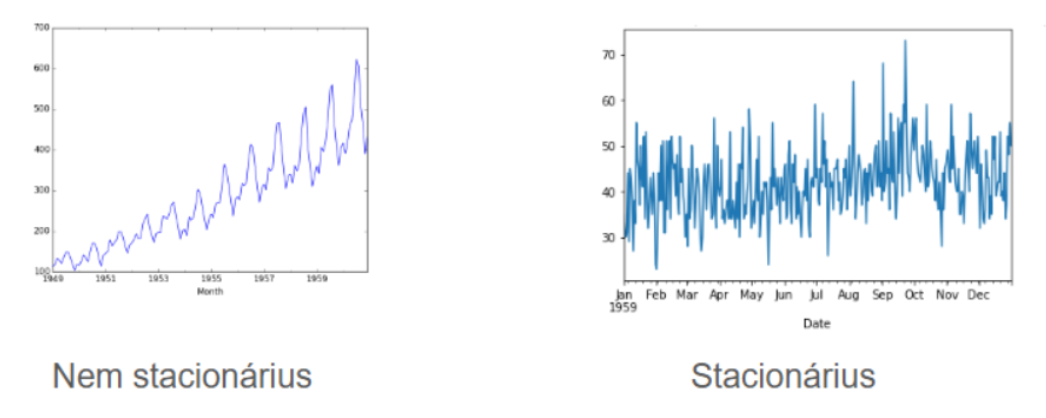
  <p style="font-style:italic; color:gray; margin-top:6px;">
    5. ábra. – Mit jelent a stacionárius jel
  </p>
</div>

Mivel az idősorunk trendet mutat (folyamatos növekedés az évek során),azt **egyszer differenciálva** (az egymást követő értékek különbségét véve) eltávolíthatjuk a trendet és **stacionáriussá tehetjük**.

Ezért:  
- d = 1 → egy differenciálás után az idősor stacionáriussá válik.


**Mit jelent a differenciálás?**

$$
y'_t = y_t - y_{t-1}
$$

Vagyis minden értékből kivonjuk az előzőt.  
Ezzel:
- a **trend megszűnik**,  
- a **változások sebességét** (nem az abszolút értéket) modellezzük,  
- és az ACF/PACF diagramok **stabilabb mintázatot** mutatnak.



<div style="background-color:#f5f0ff; border-left:6px solid #a855f7; padding:12px; border-radius:8px;">
<b>Összefoglalás:</b><br>

| Paraméter | Meghatározás | Forrás |
|------------|---------------|--------|
| **p = 2** | 2 lag szignifikáns a PACF-ben | PACF ábra |
| **d = 1** | egyszeri differenciálás után stacionárius | Trend eltávolítása |
| **q = 2** | 2 lag szignifikáns az ACF-ben | ACF ábra |
</div>






In [86]:
from statsmodels.tsa.arima.model import ARIMA

# 1. Modell létrehozása (pl. p=2, d=1, q=2)
model = ARIMA(df['Passengers'], order=(2,1,2))  # ARIMA(p,d,q)
model_fit = model.fit()

# 2. Előrejelzés (pl. 12 hónapra)
forecast = model_fit.forecast(steps=12)

# 3. Kiírás
print(forecast)


1961-01-01    439.855255
1961-02-01    465.297154
1961-03-01    500.666574
1961-04-01    535.971525
1961-05-01    561.688616
1961-06-01    571.311586
1961-07-01    562.970638
1961-08-01    539.727597
1961-09-01    508.527041
1961-10-01    478.147124
1961-11-01    456.748170
1961-12-01    449.698689
Freq: MS, Name: predicted_mean, dtype: float64


C:\Users\koros\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\koros\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\koros\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\koros\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


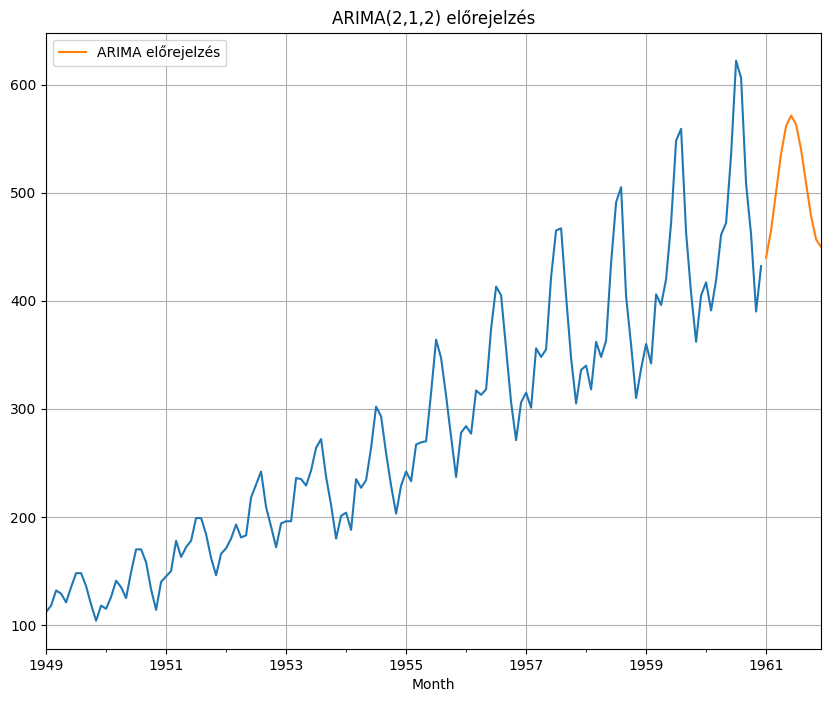

In [87]:
df['Passengers'].plot(label='Eredeti')
forecast.plot(label='ARIMA előrejelzés', legend=True)
plt.title("ARIMA(2,1,2) előrejelzés")
plt.grid(True)
plt.show()


### 22. Előrejelzés lineáris regresszióval

A **lineáris regresszió** az egyik legegyszerűbb előrejelzési módszer,amely az adatok közötti **lineáris kapcsolatot** keresi meg.  
Idősorokra is alkalmazható, ha az időt **numerikus változóként** kezeljük.



In [89]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Adat betöltése
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv")
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Időtengely numerikus alakra transzformálása
df['Time'] = np.arange(len(df))  # 0, 1, 2, ..., n-1


In [90]:
# Modell betanítása
X = df[['Time']]
y = df['Passengers']

model = LinearRegression()
model.fit(X, y)

# Előrejelzés meglévő adatokra
df['LR_fit'] = model.predict(X)


In [91]:
# 12 hónappal tovább jósolunk
future_time = np.arange(len(df), len(df) + 12).reshape(-1, 1)
future_pred = model.predict(future_time)

# Időindex a jövőre
future_index = pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')
future_df = pd.Series(future_pred, index=future_index)


C:\Users\koros\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


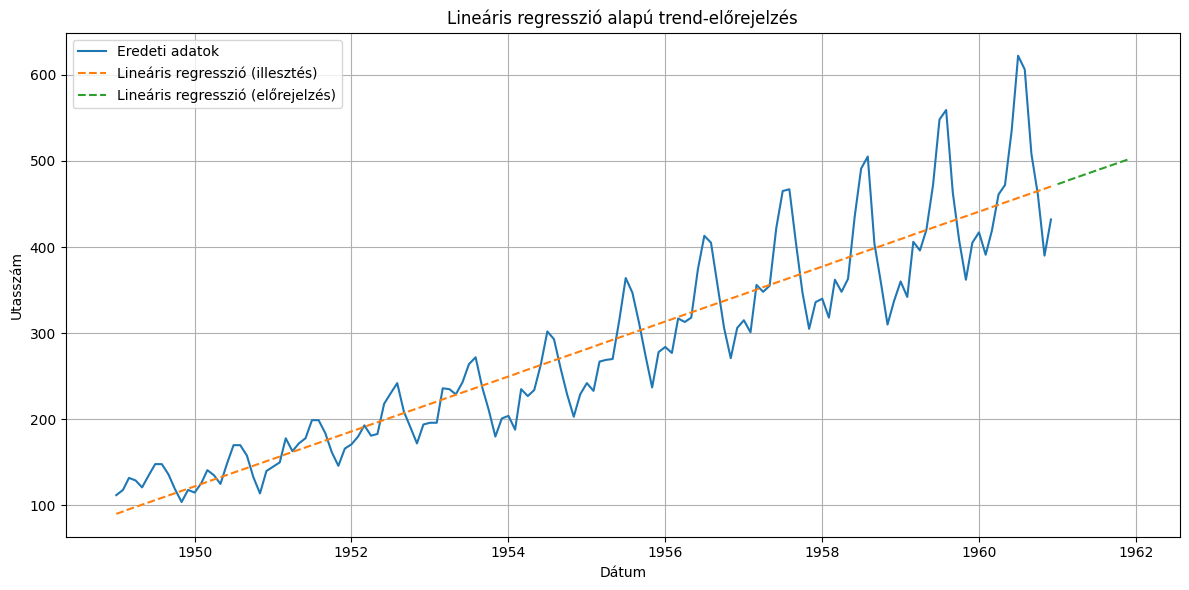

In [92]:
plt.figure(figsize=(12, 6))
plt.plot(df['Passengers'], label='Eredeti adatok')
plt.plot(df['LR_fit'], label='Lineáris regresszió (illesztés)', linestyle='--')
plt.plot(future_df, label='Lineáris regresszió (előrejelzés)', linestyle='--')
plt.title("Lineáris regresszió alapú trend-előrejelzés")
plt.xlabel("Dátum")
plt.ylabel("Utasszám")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 23. Előre jelzés a classzikus „lag features” módszerrel

- megoldás arra, hogyan alakítunk idősor előrejelzési problémát regressziós problémává.
- Ez már egy supervised learning típusú idősortanulás, ahol a cél az, hogy: A múlt értékeiből tanuljuk meg megjósolni a következő időpontot.

Ötlet:
- Az előző 10 időpont értékéből (t-1, t-2, ..., t-10) feature-öket készítünk, és ezek alapján tanítunk egy modellt, hogy megjósolja az y_t aktuális értéket.

In [95]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# 1. Adat betöltése
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv")
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# 2. Lag feature-ök generálása (pl. t-1 ... t-10)
for lag in range(1, 11):
    df[f'lag_{lag}'] = df['Passengers'].shift(lag)

# 3. Előrejelzendő célváltozó (aktuális érték)
df.dropna(inplace=True)  # Az első 10 sor NaN lesz

X = df[[f'lag_{i}' for i in range(1, 11)]]
y = df['Passengers']

# 4. Lineáris regressziós modell
model = LinearRegression()
model.fit(X, y)

# 5. Előrejelzés
df['Prediction'] = model.predict(X)


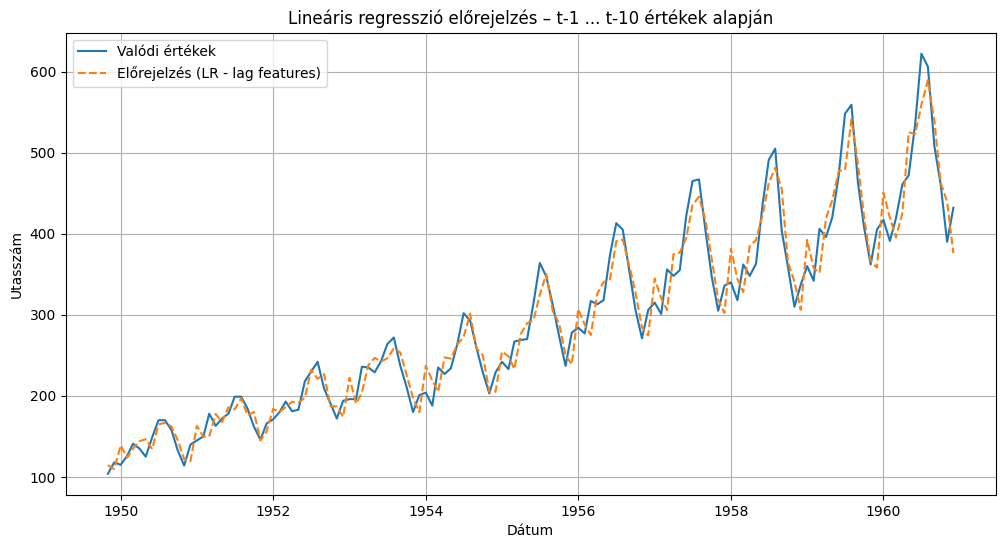

In [96]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Passengers'], label='Valódi értékek')
plt.plot(df.index, df['Prediction'], label='Előrejelzés (LR - lag features)', linestyle='--')
plt.title("Lineáris regresszió előrejelzés – t-1 ... t-10 értékek alapján")
plt.xlabel("Dátum")
plt.ylabel("Utasszám")
plt.legend()
plt.grid(True)
plt.show()
